In [ ]:
# Conditioning on the particle type, masking the velocity field, using EB weights
# Also masking out MET eta

In [2]:
!pip install --user torchcfm

DEPRECATION: Loading egg at /global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages/torchvision-0.21.0+7af6987-py3.12-linux-x86_64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages/setuptools-75.8.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages/pillow-11.1.0-py3.12-linux-x86_64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
  U

In [4]:
import sys
print(sys.executable)

/global/common/software/nersc9/pytorch/2.6.0/bin/python


In [5]:
!{sys.executable} -m pip install --user --upgrade torchdyn

DEPRECATION: Loading egg at /global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages/torchvision-0.21.0+7af6987-py3.12-linux-x86_64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages/setuptools-75.8.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages/pillow-11.1.0-py3.12-linux-x86_64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [9]:
# Troubleshooting TorchDyn Installation Issues

# 1. First, let's check what Python paths are being used
import sys
print("Python executable:", sys.executable)
print("\nPython path:")
for path in sys.path:
    print(f"  {path}")

# 2. Try to find where torchdyn might be installed
import os
import glob

# Check common installation locations
possible_paths = [
    "/global/homes/m/mcohen54/.local/perlmutter/pytorch2.6.0/lib/python3.12/site-packages/torchdyn*",
    "/global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages/torchdyn*"
]

print("\n" + "="*50)
print("SEARCHING FOR TORCHDYN INSTALLATION")
print("="*50)

for pattern in possible_paths:
    matches = glob.glob(pattern)
    if matches:
        print(f"Found torchdyn at: {matches}")
    else:
        print(f"No torchdyn found at: {pattern}")

# 3. Try to manually add the path and import
print("\n" + "="*50)
print("ATTEMPTING MANUAL PATH ADDITION")
print("="*50)

# Add the user's local site-packages to path if not already there
user_site_packages = "/global/homes/m/mcohen54/.local/perlmutter/pytorch2.6.0/lib/python3.12/site-packages"
if user_site_packages not in sys.path:
    sys.path.insert(0, user_site_packages)
    print(f"Added {user_site_packages} to Python path")

# Now try importing
try:
    from torchdyn.core import NeuralODE
    print("✅ Successfully imported NeuralODE from torchdyn!")
except ImportError as e:
    print(f"❌ Still cannot import torchdyn: {e}")
    
    # Let's check what's actually in the torchdyn directory
    torchdyn_path = os.path.join(user_site_packages, "torchdyn")
    if os.path.exists(torchdyn_path):
        print(f"\nTorchDyn directory exists at: {torchdyn_path}")
        print("Contents:")
        for item in os.listdir(torchdyn_path):
            print(f"  {item}")
    else:
        print(f"\nTorchDyn directory does not exist at: {torchdyn_path}")

# 4. Alternative: Try installing torchdyn in a different way
print("\n" + "="*50)
print("ALTERNATIVE INSTALLATION METHODS")
print("="*50)

print("If the above doesn't work, try these commands in your terminal:")
print("1. pip uninstall torchdyn")
print("2. pip install --user --no-cache-dir torchdyn")
print("   or")
print("3. pip install --user --force-reinstall torchdyn")
print("   or")
print("4. pip install --user torchdyn --upgrade --force-reinstall")

# 5. Check if there are any missing dependencies
print("\n" + "="*50)
print("CHECKING PYTORCH COMPATIBILITY")
print("="*50)

try:
    import torch
    print(f"PyTorch version: {torch.__version__}")
    print(f"CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"CUDA version: {torch.version.cuda}")
except ImportError:
    print("❌ PyTorch not available")

# 6. Environment information
print("\n" + "="*50)
print("ENVIRONMENT INFORMATION")
print("="*50)

print(f"PYTHONPATH: {os.environ.get('PYTHONPATH', 'Not set')}")
print(f"PATH: {os.environ.get('PATH', 'Not set')[:200]}...")  # Truncated for readability

Python executable: /global/common/software/nersc9/pytorch/2.6.0/bin/python

Python path:
  /opt/nersc/pymon
  /global/common/software/nersc9/pytorch/2.6.0/lib/python312.zip
  /global/common/software/nersc9/pytorch/2.6.0/lib/python3.12
  /global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/lib-dynload
  
  /global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages
  /global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages/torchvision-0.21.0+7af6987-py3.12-linux-x86_64.egg
  /global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages/pillow-11.1.0-py3.12-linux-x86_64.egg
  /global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages/setuptools-75.8.0-py3.12.egg
  /global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages/setuptools/_vendor

SEARCHING FOR TORCHDYN INSTALLATION
Found torchdyn at: ['/global/homes/m/mcohen54/.local/perlmutter/pytorch2.6.0/lib/python3.12/site-packages/torchdyn-1.0.6.dist-info', '

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from torchdyn.core import NeuralODE
from torchcfm.conditional_flow_matching import ExactOptimalTransportConditionalFlowMatcher
from matplotlib import animation
import numpy as np
import load_and_preprocess as lap
import train_and_eval_functions as taef
import os
import matplotlib.pyplot as plt
import math
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
import h5py
import os
from pathlib import Path

In [7]:
__label = 'otfm_EB_sigma0p01_v3'
save_path = '/global/homes/m/mcohen54/ctfm_development/trained_models/trial_7'
os.makedirs(save_path, exist_ok=True)
plots_path = save_path+'/plots'
os.makedirs(plots_path, exist_ok=True)


# Write the settings file
log = "Conditioning on the particle type, masking the velocity field and MET eta, using EB weights"
file_path = os.path.join(save_path, 'experiment_log.txt')
with open(file_path, 'w') as f:
    f.write(log)

batchSize = 512
numberOfEpochs = 20
patience = 5

pxpypz = True
p_train = 0.5
p_test = 0.25


input_dim = 3
model_dim = 128
ff_dim = 128
num_heads = 4
num_layers = 4
n_mask_vals = 5 # 4 particle types + 1 padding

flowSigma = 0.01

trained = True
multiGPU = True


if not multiGPU:
    os.environ["CUDA_VISIBLE_DEVICES"]="0"

In [8]:
def load_subdicts_from_h5(save_dir, tags_to_use=None):
    """
    Loads sub-dictionaries of NumPy arrays from HDF5 files in a directory and reconstructs the original structure.
    
    Args:
        save_dir (str): The directory where the HDF5 files are stored.
    
    Returns:
        main_dict (dict): A dictionary of dictionaries where the innermost values are NumPy arrays.
    """
    main_dict = {}
    
    for filename in os.listdir(save_dir):
        if filename.endswith(".h5") and not filename.startswith('.'):

            
            sub_dict_name = os.path.splitext(filename)[0]
            if tags_to_use is not None and sub_dict_name not in tags_to_use:
                continue
            file_path = os.path.join(save_dir, filename)
            with h5py.File(file_path, 'r') as f:
                sub_dict = {key: np.array(f[key]) for key in f}
            main_dict[sub_dict_name] = sub_dict
            print(f"Loaded {sub_dict_name} from {file_path}")
    
    return main_dict

In [10]:
label_map = {
    'mc23e_HNLeemu' : r"$\mathrm{HNL}\;\to\; e\,e\,\mu,\;m=7.5\,\mathrm{GeV},\;\tau=1\,\mathrm{ns}$",
    'mc23e_HAHMggf' : r"$\mathrm{HAHM}\,ggF\,h\to Z_{d}Z_{d}\to2\ell2\nu, m_{h}=125\,\mathrm{GeV}, m_{Z_{d}}=28\,\mathrm{GeV}$",
    #'mc23e_new_HtoSUEP_VBF_fullhad_125_3p00_4p00_VBFFilter' : r'VBF $h\to\mathrm{SUEP}\to\text{full-had}$ (VBF filter)',
    'mc23e_new_HtoSUEP_ggH_fullhad_125_3p00_3p00_noFilter' : r'ggF $h\to\mathrm{SUEP}\to\text{full-had}$',
    'mc23e_new_VBF_H125_a55a55_4b_ctau1_filtered' : r'VBF $h\to a_{55~\mathrm{GeV}}a_{55~\mathrm{GeV}} \to 4b$, $\tau_a = 1$ ns',
    'mc23e_new_Znunu_FxFx3jHT2bias_SW_pTvv70_BFilter' : r'$Z\to\nu\nu$ ($b$ filter)',
    'mc23e_new_ggF_H125_a16a16_4b_ctau10_filtered' : r'ggF $h\to a_{16~\mathrm{GeV}}a_{16~\mathrm{GeV}} \to 4b$, $\tau_a = 10$ ns (jet-$p_{\mathrm{T}}$ filter)',
    'mc23e_new_hh_bbbb_vbf_novhh_5fs_l1cvv1cv1' : r'VBF $hh\to 4b$',
    'EB': 'EB'
}
datasets = load_subdicts_from_h5(save_dir='/pscratch/sd/m/mcohen54/data/loaded_and_matched_data/matched_datasets')
tags_to_remove = [key for key in datasets if key not in label_map]
for tag in tags_to_remove:
    del datasets[tag]


for tag, data_dict in datasets.items():
    # Insert 0 as second to last item (MET eta) to make length 45, then reshape to (N, 15, 3)
    data_dict['data'] = np.insert(data_dict['data'], -1, 0, axis=1)
    data_dict['data'] = data_dict['data'].reshape(-1, 15, 3)

    # Remove events with no objects (all pt=0)
    has_objects = np.any(data_dict['data'][:, :, 0] > 0, axis=1)
    for key in data_dict:
        data_dict[key] = data_dict[key][has_objects]

    
    # Create particle type mask (1=jets, 2=taus, 3=muons, 4=MET)
    # Initialize mask with zeros
    mask = np.zeros((data_dict['data'].shape[0], 15))
    
    # Set mask values only where objects exist (pt > 0)
    jets_exist = data_dict['data'][:, :6, 0] > 0  # First 6 objects are jets
    taus_exist = data_dict['data'][:, 6:10, 0] > 0  # Next 4 are taus
    muons_exist = data_dict['data'][:, 10:14, 0] > 0  # Next 4 are muons
    met_exist = data_dict['data'][:, 14, 0] > 0  # Last one is MET
    
    # Apply masks only where objects exist
    mask[:, :6][jets_exist] = 1  # Jets
    mask[:, 6:10][taus_exist] = 2  # Taus
    mask[:, 10:14][muons_exist] = 3  # Muons
    mask[:, 14][met_exist] = 4  # MET
    
    # Add mask as 4th feature
    data_dict['data'] = np.dstack((data_dict['data'], mask))  # Shape becomes (N, 15, 4)

# split data in train/test/val
p_train = 0.5
p_test = 0.35
idxs = np.arange(len(datasets['EB']['data']))
train_idxs, _idxs = train_test_split(idxs, train_size=p_train, random_state=42)
test_size = p_test / (1 - p_train)
test_idxs, val_idxs = train_test_split(_idxs, train_size=test_size, random_state=42)
datasets['EB_train'] = {key: value[train_idxs] for key, value in datasets['EB'].items()}
datasets['EB_test'] = {key: value[test_idxs] for key, value in datasets['EB'].items()}
datasets['EB_val'] = {key: value[val_idxs] for key, value in datasets['EB'].items()}
del datasets['EB']

for tag, data_dict in datasets.items():
    print(f"{tag}:")
    for key, value in data_dict.items():
        print(f'  {key}: {value.shape}')

Loaded mc23e_HAHMggf from /pscratch/sd/m/mcohen54/data/loaded_and_matched_data/matched_datasets/mc23e_HAHMggf.h5
Loaded mc23e_new_HtoSUEP_ggH_fullhad_125_3p00_3p00_noFilter from /pscratch/sd/m/mcohen54/data/loaded_and_matched_data/matched_datasets/mc23e_new_HtoSUEP_ggH_fullhad_125_3p00_3p00_noFilter.h5
Loaded EB from /pscratch/sd/m/mcohen54/data/loaded_and_matched_data/matched_datasets/EB.h5
Loaded mc23e_HNLeemu from /pscratch/sd/m/mcohen54/data/loaded_and_matched_data/matched_datasets/mc23e_HNLeemu.h5
Loaded mc23e_new_VBF_H125_a55a55_4b_ctau1_filtered from /pscratch/sd/m/mcohen54/data/loaded_and_matched_data/matched_datasets/mc23e_new_VBF_H125_a55a55_4b_ctau1_filtered.h5
Loaded mc23e_new_hh_bbbb_vbf_novhh_5fs_l1cvv1cv1 from /pscratch/sd/m/mcohen54/data/loaded_and_matched_data/matched_datasets/mc23e_new_hh_bbbb_vbf_novhh_5fs_l1cvv1cv1.h5
Loaded mc23e_new_ggF_H125_a16a16_4b_ctau10_filtered from /pscratch/sd/m/mcohen54/data/loaded_and_matched_data/matched_datasets/mc23e_new_ggF_H125_a16a

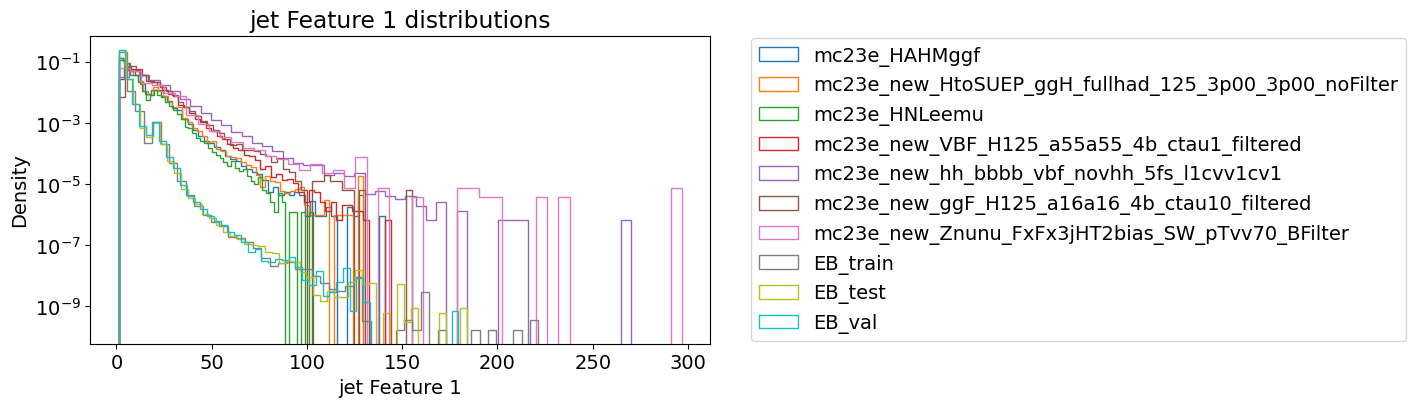

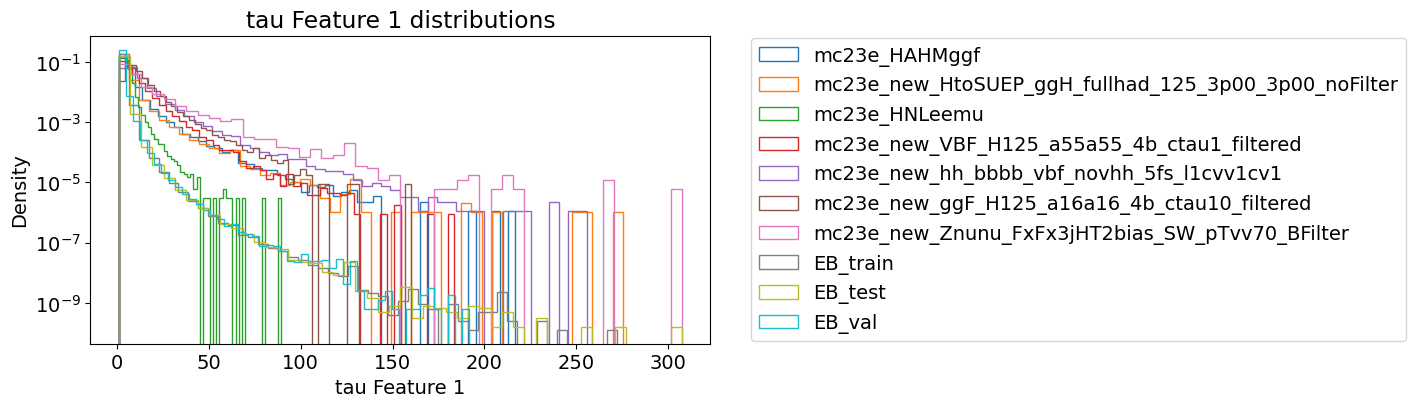

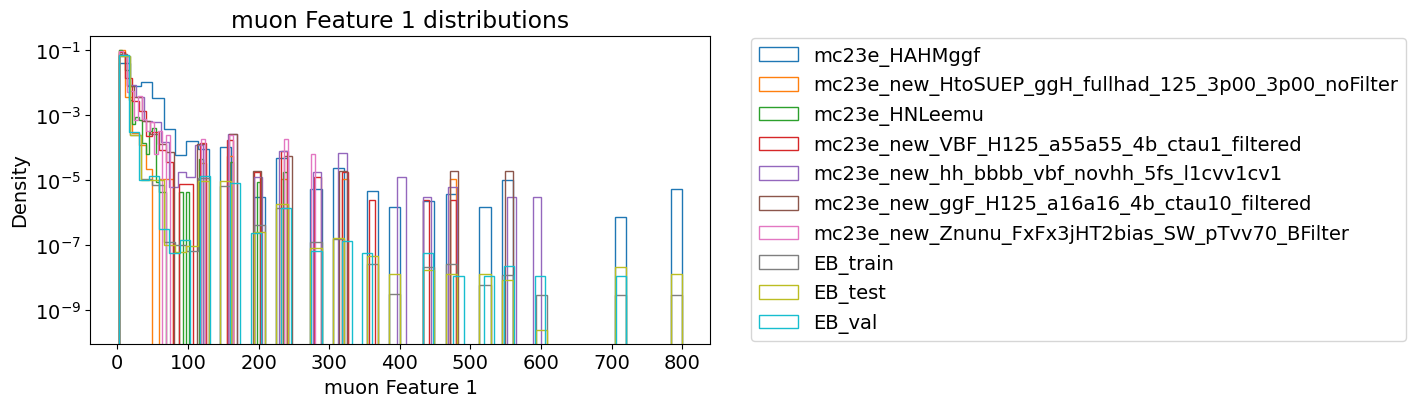

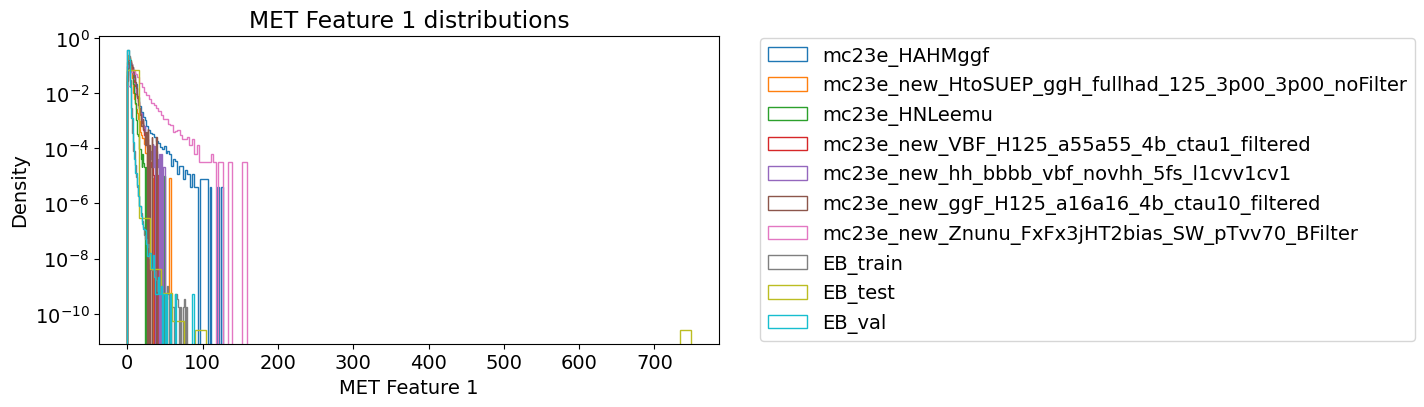

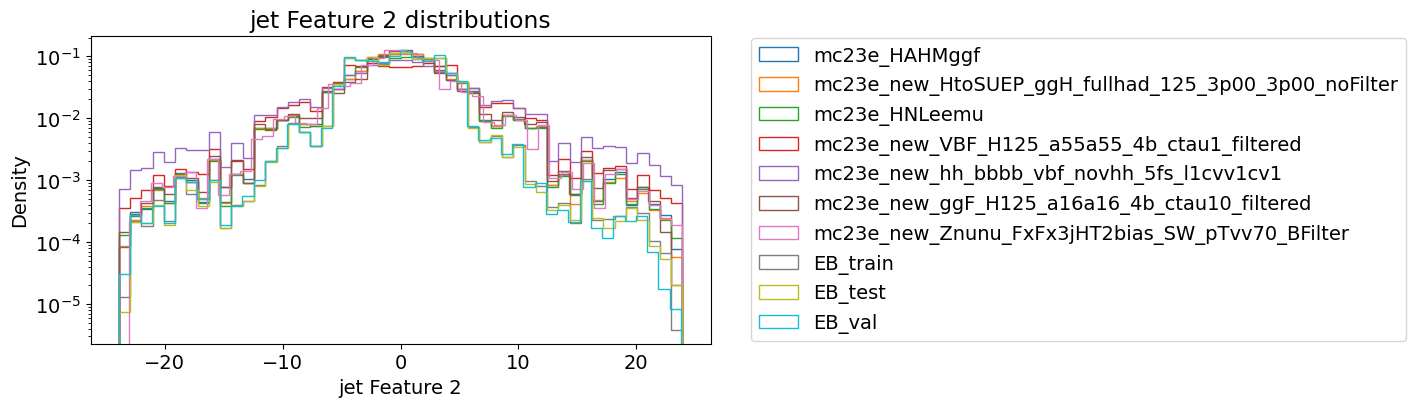

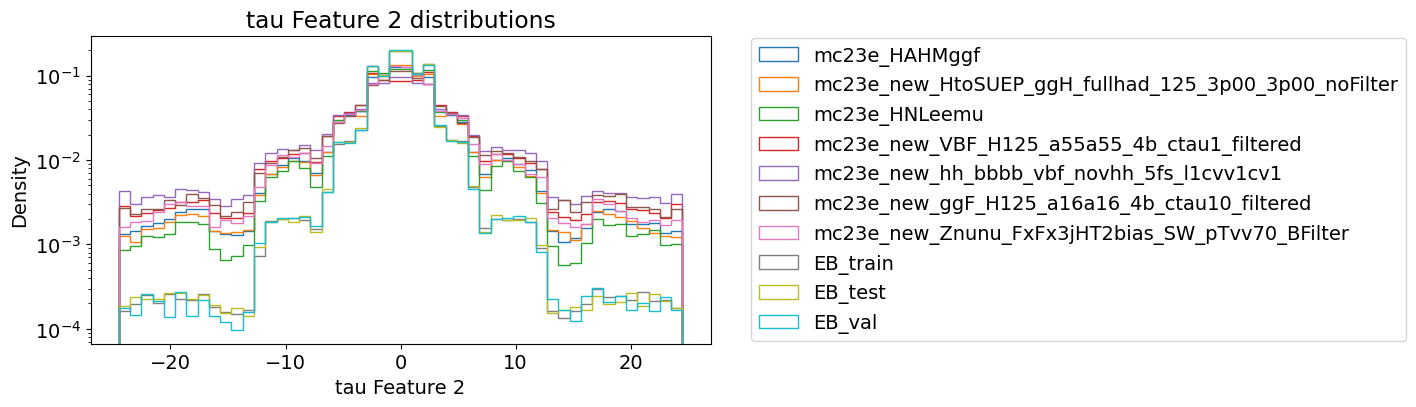

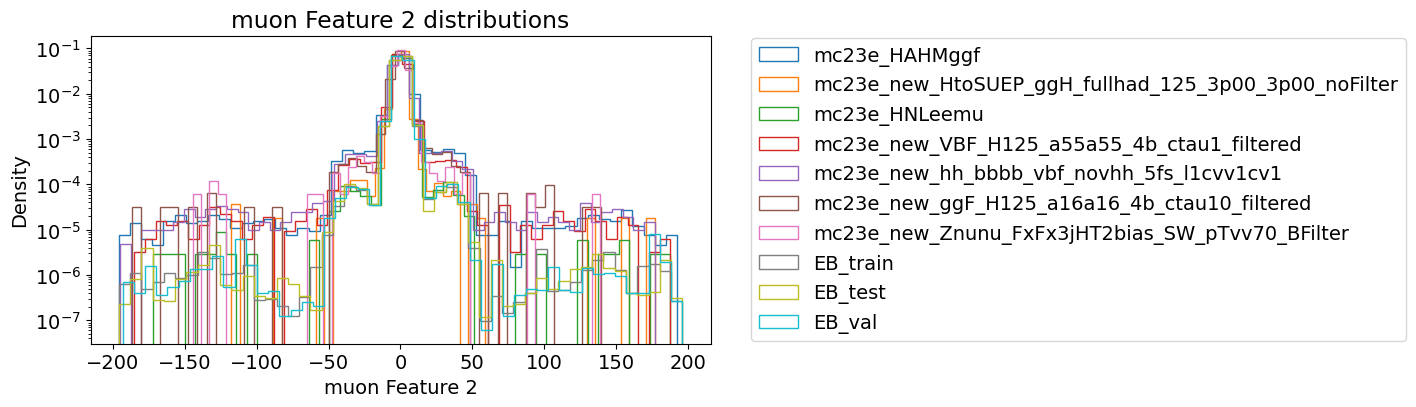

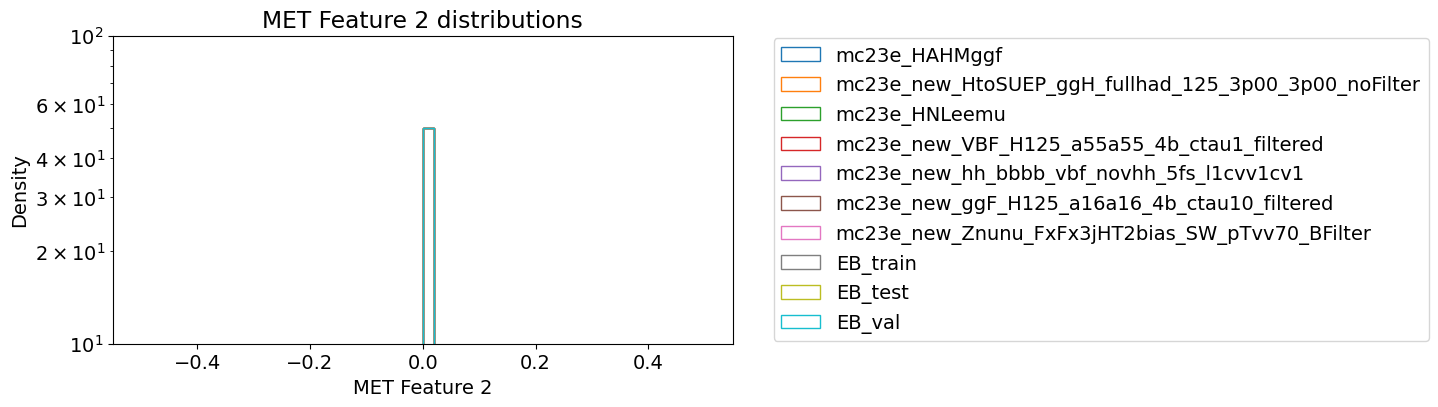

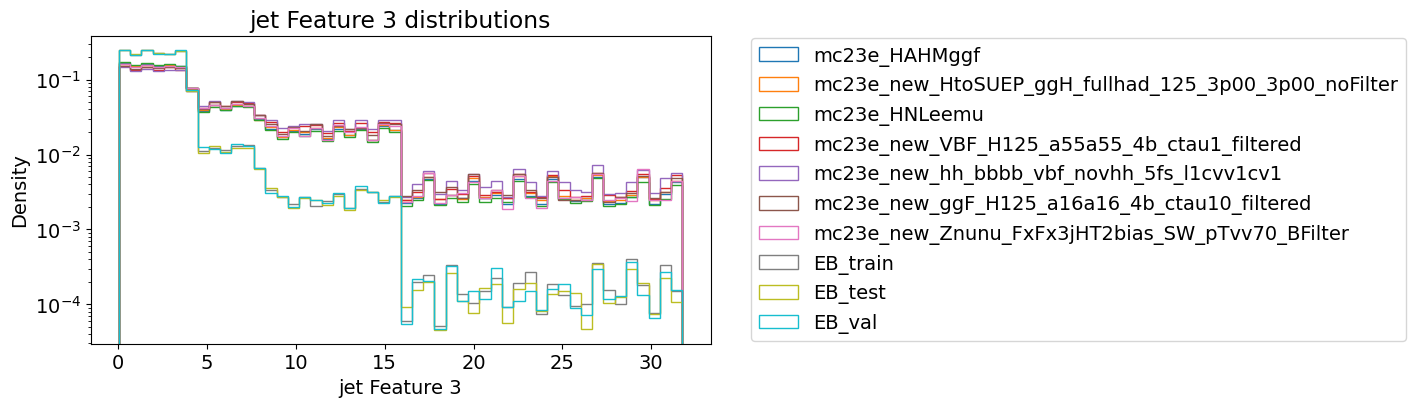

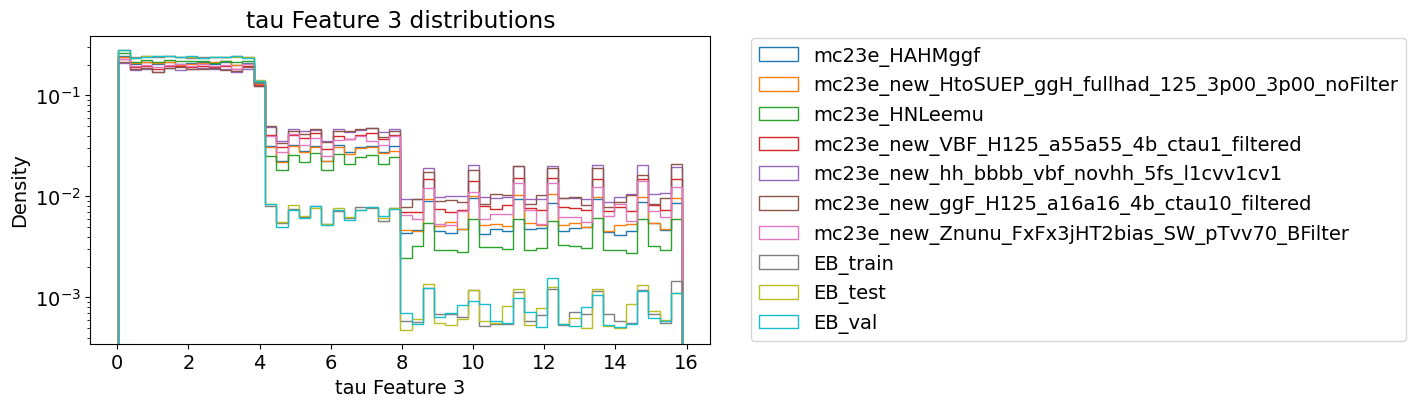

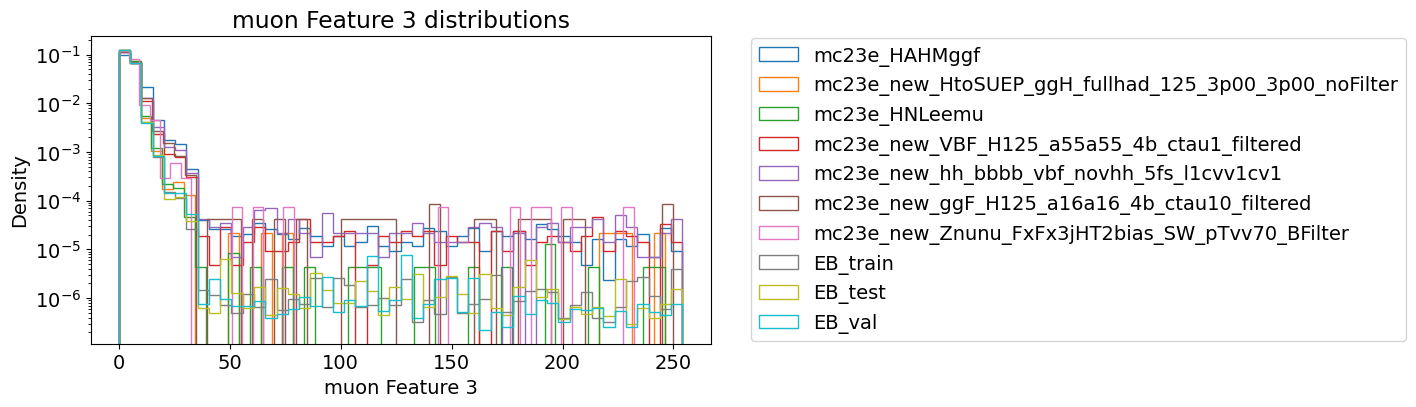

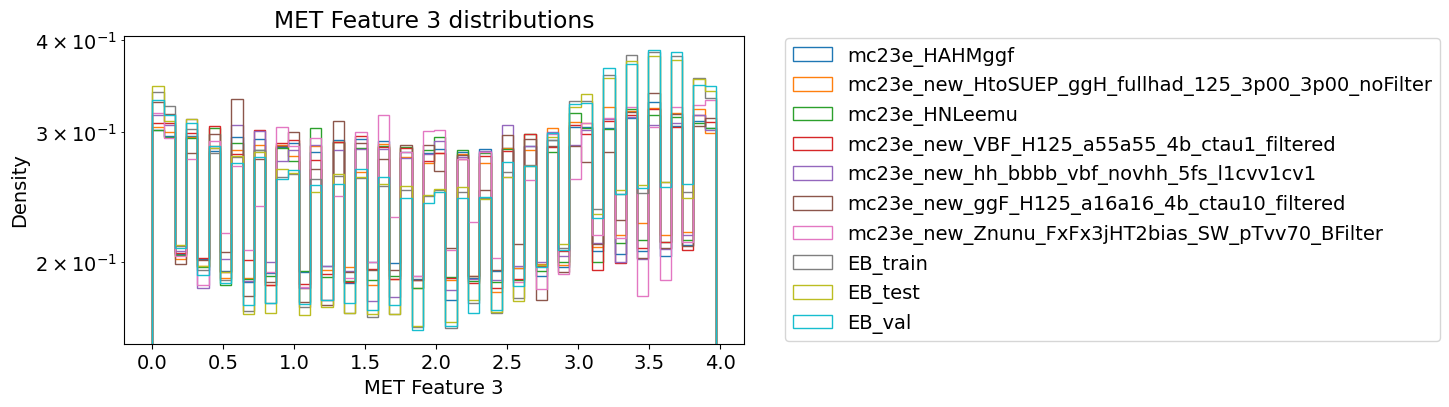

In [11]:
feature_names = ['Feature 1', 'Feature 2', 'Feature 3']
object_types = {1: 'jet', 2: 'tau', 3: 'muon', 4: 'MET'}
colors = ['C0', 'C1', 'C2', 'C3']

# data = datasets['EB_train']['data']
# for i, feat_name in enumerate(feature_names):
#     plt.figure(figsize=(8, 4))
#     for obj_type, label in object_types.items():
#         mask = data[:, :, 3] == obj_type
#         values = data[:, :, i][mask]
#         if len(values) > 0:
#             plt.hist(values, bins=50, histtype='step', density=True,
#                      label=label, color=colors[obj_type-1])
#     plt.yscale('log')
#     plt.xlabel(feat_name)
#     plt.ylabel('Density')
#     plt.title(f'{feat_name} distributions by object type (train)')
#     plt.legend()
#     plt.savefig(f"{plots_path}/input_feature_{i+1}_by_type.png")
#     plt.show()
#     plt.close()




for i, feat_name in enumerate(feature_names):
    for obj_type, label in object_types.items():
        plt.figure(figsize=(8, 4))
        for tag, data_dict in datasets.items():
            data = data_dict['data']
            weights = data_dict['weights']
            
            # build the mask of shape (N,15)
            mask = data[:, :, 3] == obj_type
            
            # get the (event,object) pairs where mask is True
            event_idx, obj_idx = np.where(mask)
            
            # extract your values for feature i
            values = data[event_idx, obj_idx, i]
            
            # extract the corresponding weights (one weight per event)
            weights_per_object = weights[event_idx]
    
            if len(values) > 0:
                plt.hist(values, bins=50, histtype='step', density=True,
                      label=tag, weights=weights_per_object)

        

        plt.yscale('log')
        plt.xlabel(label+' '+feat_name)
        plt.ylabel('Density')
        plt.title(f'{label} {feat_name} distributions')
        plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left')
        #plt.savefig(f"{plots_path}/input_feature_{i+1}_by_type.png")
        plt.show()
        plt.close()
    

In [12]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, embedding_dim, max_period=10000):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.max_period = max_period

    def forward(self, t):
        # t: [B, 1] or [B]
        half_dim = self.embedding_dim // 2
        device = t.device
        # Compute frequencies
        exponent = -math.log(self.max_period) * torch.arange(half_dim, device=device).float() / half_dim
        freqs = torch.exp(exponent)  # [half_dim]
        # Project t
        t_proj = t.float()
        if t_proj.ndim == 1:
            t_proj = t_proj[:, None]  # [B, 1]
        args = t_proj * freqs[None, :]  # [B, half_dim]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)  # [B, embedding_dim or embedding_dim-1]
        if self.embedding_dim % 2:  # pad if odd
            emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=-1)
        return emb  # [B, embedding_dim]

class TransformerVectorField(nn.Module):
    def __init__(self, input_dim=3, model_dim=128, num_heads=4, num_layers=4, 
                 n_mask_vals=5, ff_dim=512):
        super().__init__()
        self.model_dim = model_dim

        # project the 3D features
        self.input_proj = nn.Linear(input_dim, model_dim)

        # embed mask (0=pad, 1-4=particle types)
        self.mask_emb = nn.Embedding(n_mask_vals, model_dim)

        # time embedding MLP
        self.time_emb = SinusoidalTimeEmbedding(model_dim)
        self.time_mlp = nn.Sequential(
            nn.Linear(model_dim, model_dim),
            nn.SiLU(),
            nn.Linear(model_dim, model_dim)
        )

        # transformer stack
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            activation='gelu',
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # back to velocity
        self.output_proj = nn.Linear(model_dim, input_dim)

    def forward(self, t, x, mask=None, **kwargs):
        # x: [B, N, 3], mask: [B, N, 1]
        B, N, _ = x.shape

        # 1) feature projection
        h = self.input_proj(x)                          # [B, N, model_dim]

        # 2) mask embedding and injection
        if mask is not None:
            m = mask.squeeze(-1).long()                        # [B, N]
            m_emb = self.mask_emb(m)                    # [B, N, model_dim]
            h = h + m_emb

        # 3) time embedding
        if isinstance(t, float) or t.ndim == 0:
            t = torch.full((B, 1), float(t), device=x.device)
        elif t.ndim == 1:
            t = t.view(-1, 1)
        time_emb = self.time_emb(t)                     # [B, model_dim]
        time_emb = self.time_mlp(time_emb)              # [B, model_dim]
        time_emb = time_emb[:, None, :]                 # [B, 1, model_dim]
        h = h + time_emb                                # broadcast to [B, N, model_dim]

        # 4) transformer with padding mask
        src_key_padding_mask = None
        if mask is not None:
            # mask==0 indicates padding positions
            src_key_padding_mask = (mask.squeeze(-1) == 0)  # [B, N] boolean
        h = self.transformer(h, src_key_padding_mask=src_key_padding_mask)

        # 5) output velocity
        v = self.output_proj(h)                         # [B, N, 3]
        # zero out velocities on padded slots
        if mask is not None:
            binary_mask = (mask > 0).float()   # [B, N, 1]: 1 if particle exists, 0 if padded
            v = v * binary_mask

        # zero out MET eta velocity component (always mask this)
        v[:, -1, 1] = 0  # MET eta velocity = 0
        
        return v

In [13]:
def train(model, dataloader, optimizer, device, num_epochs=50, sigma=0.0):
    model.to(device)
    # flow matcher does not support conditioning directly; we embed and mask slots instead
    FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma)

    for epoch in range(num_epochs):
        total_loss = 0.
        for i, (x1, mask, weights) in enumerate(tqdm(dataloader)):
            x1 = x1.to(device)
            mask = mask.to(device)
            weights = weights.to(device)
            optimizer.zero_grad()

            # sample noise
            x0 = torch.randn_like(x1)
            # sample flow-matching tuples with condition
            t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)

            # model prediction
            vt = model(t, xt, mask=mask)
            # mask ground-truth velocity
            binary_mask = (mask > 0).float()            # [B, N, 1]
            ut = ut * binary_mask

            # zero out MET eta velocity component in ground truth (consistent with model)
            ut[:, -1, 1] = 0  # MET eta velocity = 0

            # compute per-event loss
            mask_expanded = binary_mask.expand_as(vt)
            sq_err = (vt - ut)**2
            per_event_loss = torch.sum(sq_err * mask_expanded, dim=[1,2])  # [B]

            # weighted mean loss
            weighted_loss = (per_event_loss * weights).sum() / weights.sum()
            weighted_loss.backward()
            optimizer.step()

            total_loss += weighted_loss.item()

        avg_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch+1} - Loss: {avg_loss:.6f}")

In [14]:
class EvtDataset(Dataset):
    def __init__(self, evts, weights):  # Add weights argument
        self.x = evts[:, :, :3]           # [eta, phi, pt]
        self.mask = evts[:, :, 3:]        # [mask]
        self.weights = weights            # [num_events]

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx], self.mask[idx], self.weights[idx]  # Return weight

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"

dataset = EvtDataset(
    datasets['EB_train']['data'].astype(np.float32),
    datasets['EB_train']['weights'].astype(np.float32)
)
dataloader = DataLoader(dataset, batch_size=batchSize, shuffle=True, drop_last=True)

model = TransformerVectorField(input_dim=input_dim, model_dim=model_dim, num_heads=num_heads, num_layers=num_layers)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

if not trained:
    train(model, dataloader, optimizer, device=device, num_epochs=numberOfEpochs, sigma=flowSigma)
    
    # Assuming `node` is your trained NeuralODE (e.g., torchcfm.NeuralODE)
    torch.save({
        'state_dict': model.state_dict(),
        'model_kwargs': {
            'input_dim': input_dim,
            'model_dim': model_dim,
            'num_heads': num_heads,
            'num_layers': num_layers
        }
    }, f"{save_path}/{__label}.pt")

else:
    # Rebuild the vector field
    ckpt = torch.load(f"{save_path}/{__label}.pt", map_location=device)
    
    # Recreate the architecture
    model = TransformerVectorField(**ckpt['model_kwargs'])
    model.load_state_dict(ckpt['state_dict'])
    model.to(device).eval()

node = NeuralODE(model, solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4)

In [17]:
# # animate flows
# from matplotlib import animation

# with torch.no_grad():
#     traj = node.trajectory(
#         torch.randn(100, sel_train.shape[1], 3, device=device),
#         t_span=torch.linspace(0, 1, 20, device=device),
#     )

# traj_cpu = traj.cpu()

# gridsize = 3
# num_evts = gridsize * gridsize
# evts_to_visualize = range(num_evts)

# fig, axes = plt.subplots(gridsize, gridsize, figsize=(15, 15))
# axes = axes.flatten()
# scats = []
# for ax in axes:
#     scat = ax.scatter([], [], s=10, alpha=0.5)
#     scats.append(scat)
#     ax.set_xlim(-4, 4)
#     ax.set_ylim(-4, 4)
#     ax.set_xlabel('eta')
#     ax.set_ylabel('phi')
#     ax.set_title('Event Flow')

# def init():
#     return scats

# def update(frame):
#     for i, evt_idx in enumerate(evts_to_visualize):
#         particle_traj = cartesian_to_cylindrical(traj_cpu[:, evt_idx])
#         pos = particle_traj[frame, :, 1:3]
#         mask = particle_traj[0, :, -1]
#         sizes = 10. * particle_traj[frame, :, 0]
#         scats[i].set_offsets(pos[mask>0.5])
#         scats[i].set_sizes(sizes[mask>0.5])
#     return scats

# ani = animation.FuncAnimation(fig, update, frames=traj_cpu.shape[0],
#                               init_func=init, blit=True, interval=500)
# ani.save('event_flow_grid.gif', writer='imagemagick')
# from IPython.display import HTML
# HTML(ani.to_jshtml())

NameError: name 'sel_train' is not defined

In [16]:
def map_to_base_distribution(node, x1, mask, batch_size=1024):
    """
    Maps x1 (data space) to x0 (base space) using the inverse flow in batches.
    Applies mask to ignore padded particles.
    
    Args:
        node: A trained NeuralODE.
        x1: [B, N, D] torch.Tensor - data space samples.
        mask: [B, N, 1] torch.Tensor - binary mask for valid particles.
        batch_size: int - batch size for processing.

    Returns:
        x0: [B, N, D] torch.Tensor - mapped base samples with mask applied.
    """
    t_span = torch.linspace(1., 0., 2, device=x1.device)
    outputs = []

    for i in tqdm(range(0, x1.size(0), batch_size)):
        xb = x1[i:i+batch_size]
        mb = mask[i:i+batch_size]
        binary_mask = (mb > 0).float()

        with torch.no_grad():
            traj = node.trajectory(xb, t_span=t_span)  # [2, bsz, N, D]
            x0_b = traj[-1]  * binary_mask # apply mask

            # ensure MET eta remains 0 in base distribution
            x0_b[:, -1, 1] = 0  # MET eta = 0

        outputs.append(x0_b)

    return torch.cat(outputs, dim=0)

In [17]:
skip_tags = ['EB_val', 'EB_train']
for tag, data_dict in datasets.items():
    if tag in skip_tags:
        continue

    if 'EB' not in tag: continue
    
    torch_data = torch.tensor(data_dict['data'], dtype=torch.float32).to(device)
    torch_x = torch_data[:,:,:3]
    torch_mask = torch_data[:,:,3:]

    data_dict['x0_latent'] = map_to_base_distribution(node, torch_x, torch_mask)
    data_dict['torch_mask'] = torch_mask

    print(tag)
    print("Mapped shape:", data_dict['x0_latent'].shape)  # Should be [N, 15, 3]
    print("Latent mean (should be ~0):", data_dict['x0_latent'].mean().item())
    print("Latent std (should be ~1):", data_dict['x0_latent'].std().item())

100%|██████████| 868/868 [06:02<00:00,  2.39it/s]

EB_test
Mapped shape: torch.Size([887913, 15, 3])
Latent mean (should be ~0): 0.08636724203824997
Latent std (should be ~1): 2.8957321643829346


In [13]:
from scipy.stats import norm, stats

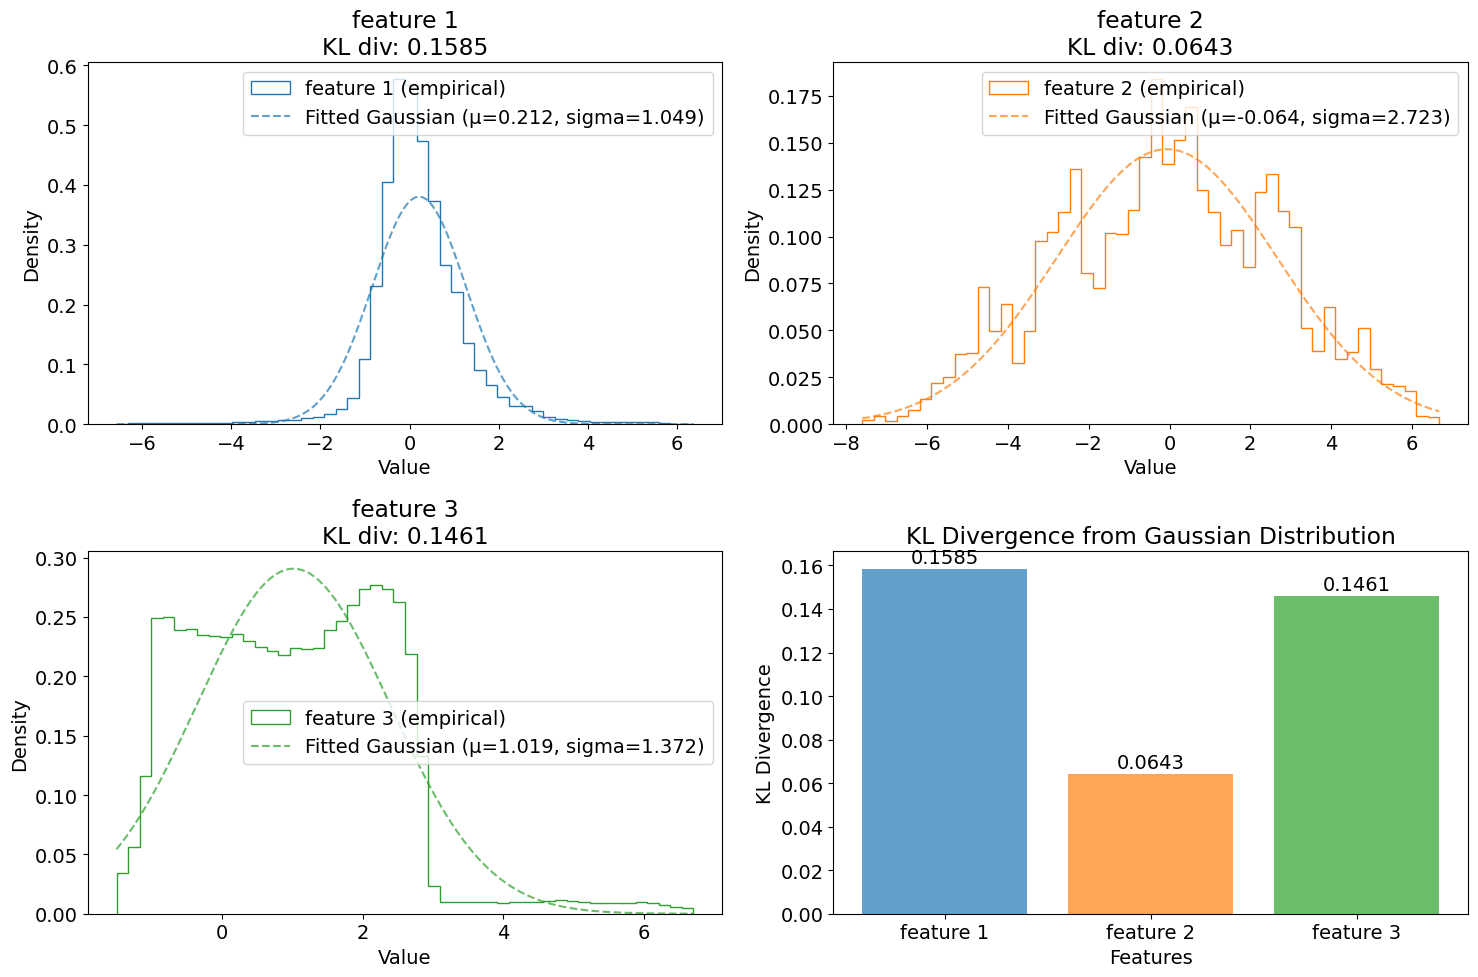

=== Gaussian Deviation Analysis ===
KL Divergence (lower = more Gaussian-like):
  feature 1: KL = 0.158521
    Fitted params: μ = 0.2124, sigma = 1.0487
  feature 2: KL = 0.064341
    Fitted params: μ = -0.0642, sigma = 2.7225
  feature 3: KL = 0.146100
    Fitted params: μ = 1.0186, sigma = 1.3723

Most Gaussian-like feature: feature 2
Least Gaussian-like feature: feature 1


In [14]:
# Plot features post flow

def get_valid_feature(data_dict, feature_idx):
    """
    Return flat (object-level) values and weights for a single feature,
    after masking out padded / invalid objects.
    """
    # raw tensors -----------------------------------------------------------
    x0      = data_dict['x0_latent'][:, :, feature_idx]   # [B, N]
    mask    = data_dict['torch_mask'].squeeze(-1) > 0.5   # [B, N] bool
    w_event = data_dict['weights'].flatten()              # [B]

    # For eta feature, exclude MET objects (last object)
    if feature_idx == 1:  # eta
        met_mask = torch.zeros_like(mask, dtype=torch.bool)  # explicitly boolean
        met_mask[:, -1] = True  # MET is the last object
        mask = mask & ~met_mask  # exclude MET from valid objects

    # broadcast weights from [B] -> [B, N] -------------------------------
    #   unsqueeze to [B,1] then expand (no mem copy) to [B, N]        
    w_all = np.broadcast_to(w_event[:, None], x0.shape)

    # flatten & keep valid objects -----------------------------------------
    x0_flat = x0.flatten()
    w_flat  = w_all.flatten()
    m_flat  = mask.flatten()

    x0_np = x0_flat[m_flat].cpu().numpy()
    #x0_np = x0_flat[m_flat]
    w_np = w_flat[m_flat.cpu().numpy()]
    return x0_np, w_np

def calculate_kl_divergence_to_gaussian(data, weights, bins=100):
    """
    Calculate KL divergence between empirical distribution and fitted Gaussian
    """
    # weighted mean and std
    mu = np.average(data, weights=weights)
    sigma = np.sqrt(np.average((data - mu) ** 2, weights=weights))
    
    # Create histogram
    hist, bin_edges = np.histogram(data, bins=bins, density=True, weights=weights)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]
    
    # Calculate empirical probabilities (normalize histogram)
    empirical_probs = hist * bin_width
    
    # Calculate theoretical Gaussian probabilities
    gaussian_probs = norm.pdf(bin_centers, mu, sigma) * bin_width
    
    # Add small epsilon to avoid log(0)
    epsilon = 1e-10
    empirical_probs = np.maximum(empirical_probs, epsilon)
    gaussian_probs = np.maximum(gaussian_probs, epsilon)
    
    # Calculate KL divergence: D_KL(P||Q) = sum(P * log(P/Q))
    # where P is empirical and Q is Gaussian
    kl_div = np.sum(empirical_probs * np.log(empirical_probs / gaussian_probs))
    
    return kl_div, mu, sigma


plt.figure(figsize=(15, 10))
feature_names = ['feature 1', 'feature 2', 'feature 3']
colors = ['C0', 'C1', 'C2']

# Store results
kl_divergences = []
gaussian_params = []

for i in range(3):
    # filter by percentiles
    data, weights = get_valid_feature(datasets['EB_test'], i)
    lower, upper = np.percentile(data, [5, 95])
    valid = (data >= lower) & (data <= upper)
    data = data[valid]
    weights = weights[valid]


    # Calculate KL divergence and fitted parameters
    kl_div, mu, sigma = calculate_kl_divergence_to_gaussian(data, weights)
    kl_divergences.append(kl_div)
    gaussian_params.append((mu, sigma))

    # Plot histogram
    plt.subplot(2, 2, i+1)
    plt.hist(data, bins=50, histtype='step', density=True, label=f'{feature_names[i]} (empirical)', color=colors[i], weights=weights)
    
    # Overlay fitted Gaussian
    x = np.linspace(data.min(), data.max(), 200)
    plt.plot(x, norm.pdf(x, mu, sigma), color=colors[i], linestyle='dashed', alpha=0.7, 
             label=f'Fitted Gaussian (μ={mu:.3f}, sigma={sigma:.3f})')
    
    plt.legend()
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.title(f'{feature_names[i]}\nKL div: {kl_div:.4f}')

# Summary plot
plt.subplot(2, 2, 4)
x_pos = np.arange(len(feature_names))
plt.bar(x_pos, kl_divergences, color=colors, alpha=0.7)
plt.xlabel('Features')
plt.ylabel('KL Divergence')
plt.title('KL Divergence from Gaussian Distribution')
plt.xticks(x_pos, feature_names)

# Add text annotations
for i, kl_div in enumerate(kl_divergences):
    plt.text(i, kl_div + 0.001, f'{kl_div:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(f'{plots_path}/gaussian_deviation_analysis.png', bbox_inches='tight')
plt.show()

# Print summary results
print("=== Gaussian Deviation Analysis ===")
print("KL Divergence (lower = more Gaussian-like):")
for i, (name, kl_div) in enumerate(zip(feature_names, kl_divergences)):
    mu, sigma = gaussian_params[i]
    print(f"  {name}: KL = {kl_div:.6f}")
    print(f"    Fitted params: μ = {mu:.4f}, sigma = {sigma:.4f}")

print(f"\nMost Gaussian-like feature: {feature_names[np.argmin(kl_divergences)]}")
print(f"Least Gaussian-like feature: {feature_names[np.argmax(kl_divergences)]}")

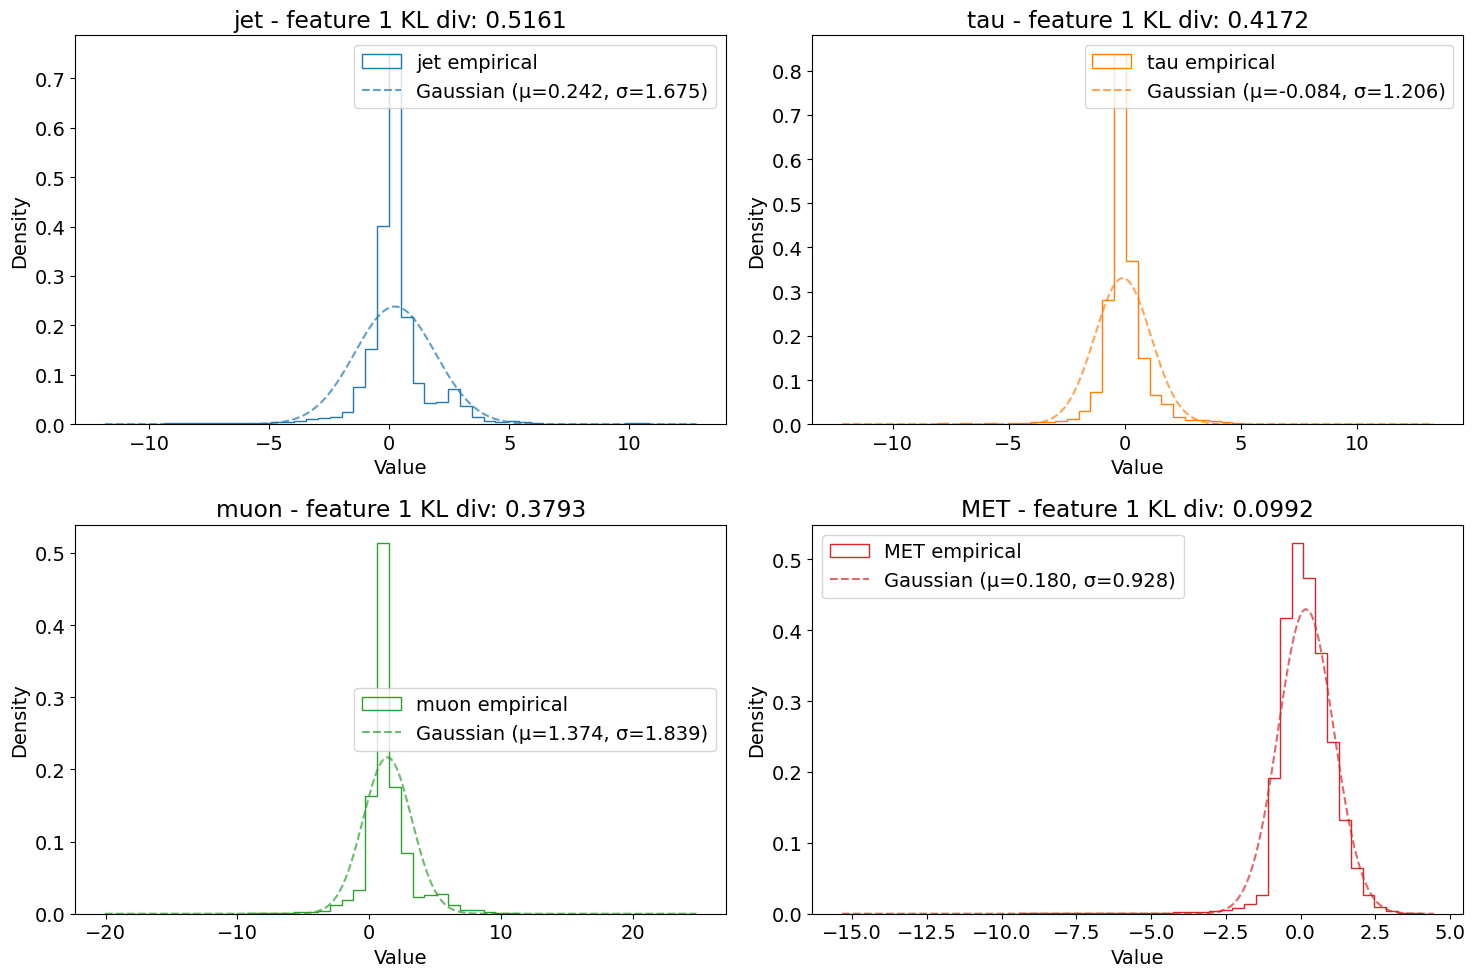

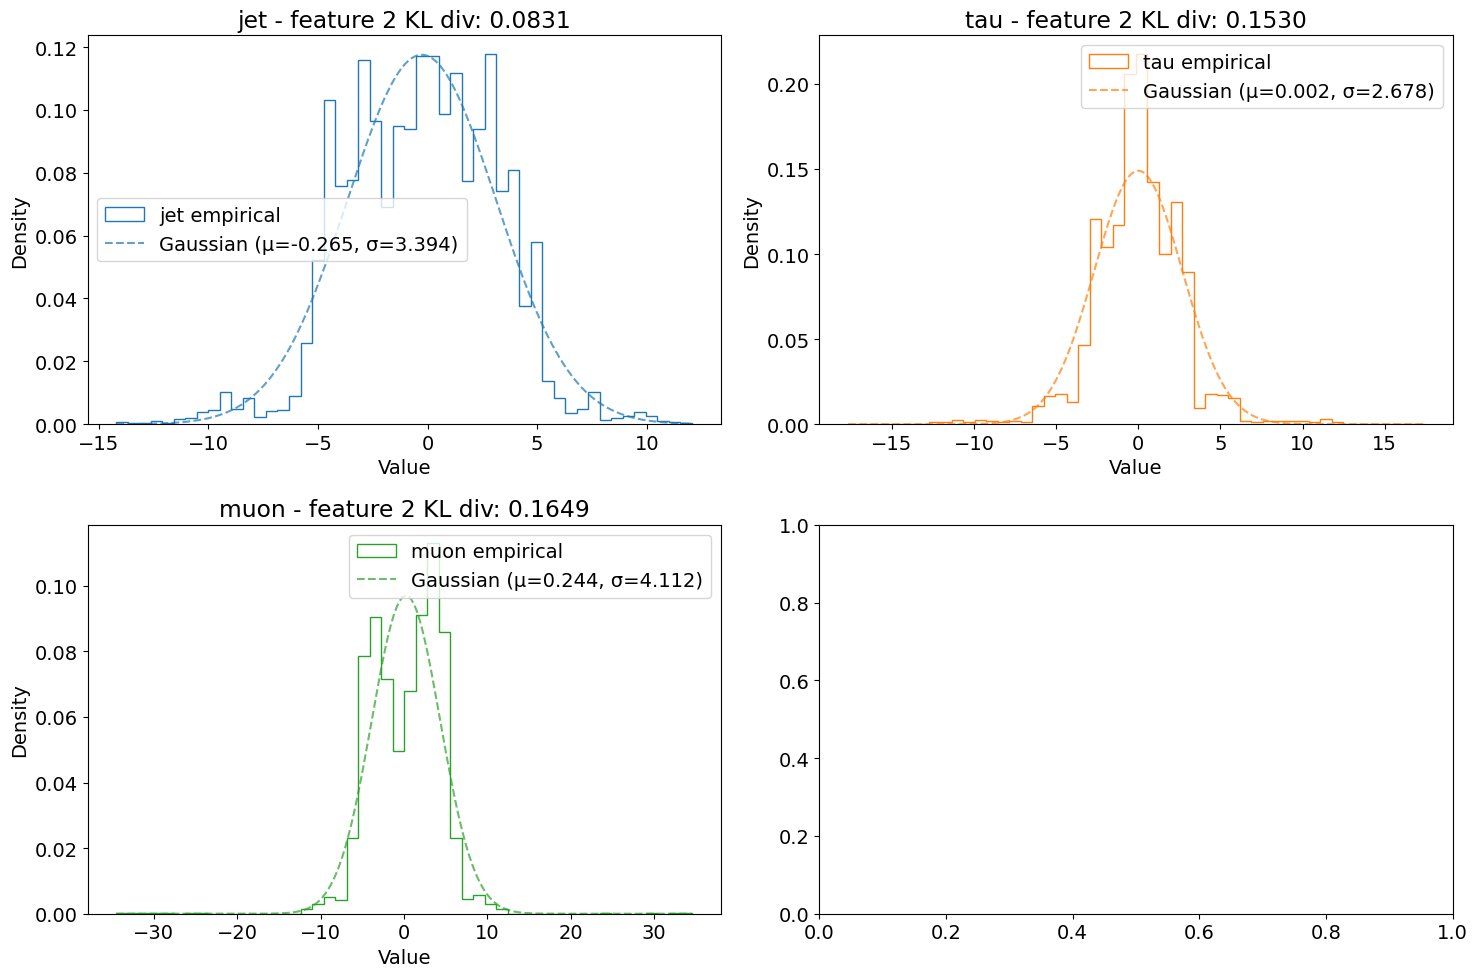

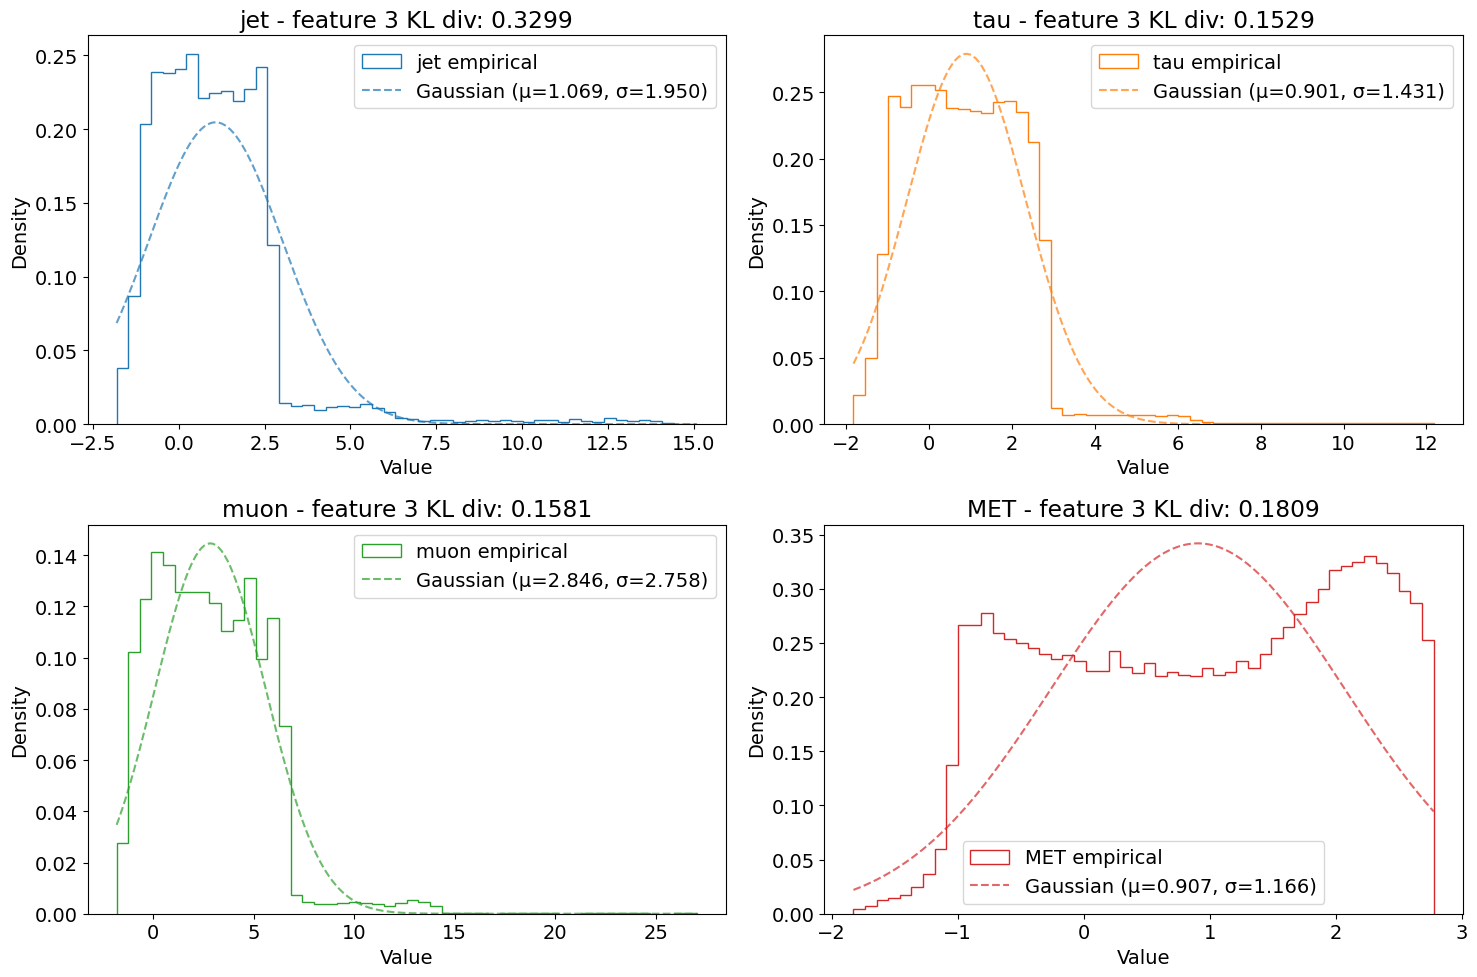

In [15]:
feature_names = ['feature 1', 'feature 2', 'feature 3']
object_types = {1: 'jet', 2: 'tau', 3: 'muon', 4: 'MET'}
colors = ['C0', 'C1', 'C2', 'C3']

for i, feat_name in enumerate(feature_names):
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    axs = axs.ravel()
    for j, (obj_type, label) in enumerate(object_types.items()):
        if label == 'MET' and feat_name == 'feature 2':
            continue
        x0 = datasets['EB_test']['x0_latent'][:, :, i]
        mask = datasets['EB_test']['torch_mask'].squeeze(-1)
        obj_mask = mask == obj_type
        weights = datasets['EB_test']['weights']
        w_all = np.broadcast_to(weights[:, None], mask.shape)
        data = x0[obj_mask].cpu().numpy()
        w = w_all[obj_mask.cpu().numpy()]
        if len(data) == 0:
            continue
        lower, upper = np.percentile(data, [1, 99])
        valid = (data >= lower) & (data <= upper)
        data = data[valid]
        w = w[valid]
        kl_div, mu, sigma = calculate_kl_divergence_to_gaussian(data, w)
        ax = axs[j]
        ax.hist(data, bins=50, histtype='step', density=True,
                label=f'{label} empirical', color=colors[j], weights=w)
        x = np.linspace(data.min(), data.max(), 200)
        ax.plot(x, norm.pdf(x, mu, sigma), color=colors[j], linestyle='dashed', alpha=0.7,
                label=f'Gaussian (μ={mu:.3f}, σ={sigma:.3f})')
        ax.set_title(f'{label} - {feat_name} KL div: {kl_div:.4f}')
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        ax.legend()
    plt.tight_layout()
    #plt.savefig(f"{plots_path}/gaussian_deviation_by_type_{i+1}.png")
    plt.show()
    plt.close()

In [16]:
def neg_log_prob_gaussian(x0, mask):
    """
    Compute -log p(x0) under a standard N-dimensional Gaussian,
    masking out invalid (padded) particles.

    Args:
        x0: [B, N, D] tensor
        mask: [B, N, 1] binary mask tensor (1 = valid, 0 = padded)

    Returns:
        nll: [B] tensor, negative log-likelihood per jet
    """
    # Standard Gaussian: log p(x) = -0.5 * (x^2 + log(2π))
    log_probs = -0.5 * (x0 ** 2 + torch.log(torch.tensor(2 * torch.pi, device=x0.device)))

    # Apply mask and sum over particles and features
    binary_mask = (mask > 0).float()
    log_probs_masked = log_probs * binary_mask  # [N, 15, 3]

    # Zero out MET eta component from NLL calculation (always 0, adds no information)
    log_probs_masked[:, -1, 1] = 0  # MET eta contribution = 0
    
    log_likelihood = log_probs_masked.sum(dim=(1, 2))  # [N]

    # Return negative log-likelihood
    return -log_likelihood  # [N]

In [17]:
for tag, data_dict in datasets.items():
    if tag in skip_tags:
        continue
    data_dict['AD_scores'] = neg_log_prob_gaussian(data_dict['x0_latent'], data_dict['torch_mask']).cpu().numpy()  # [B]
    print(tag)
    print("Weighted average AD score per event:", np.average(data_dict['AD_scores'], weights=data_dict['weights']))

mc23e_HAHMggf
Weighted average AD score per event: 759.3360317698979
mc23e_new_HtoSUEP_ggH_fullhad_125_3p00_3p00_noFilter
Weighted average AD score per event: 378.33416813238796
mc23e_HNLeemu
Weighted average AD score per event: 344.07310389993785
mc23e_new_VBF_H125_a55a55_4b_ctau1_filtered
Weighted average AD score per event: 738.1813901491928
mc23e_new_hh_bbbb_vbf_novhh_5fs_l1cvv1cv1
Weighted average AD score per event: 1180.4347033691406
mc23e_new_ggF_H125_a16a16_4b_ctau10_filtered
Weighted average AD score per event: 767.0424542533874
mc23e_new_Znunu_FxFx3jHT2bias_SW_pTvv70_BFilter
Weighted average AD score per event: 759.398795690155
EB_test
Weighted average AD score per event: 15.437182425063266


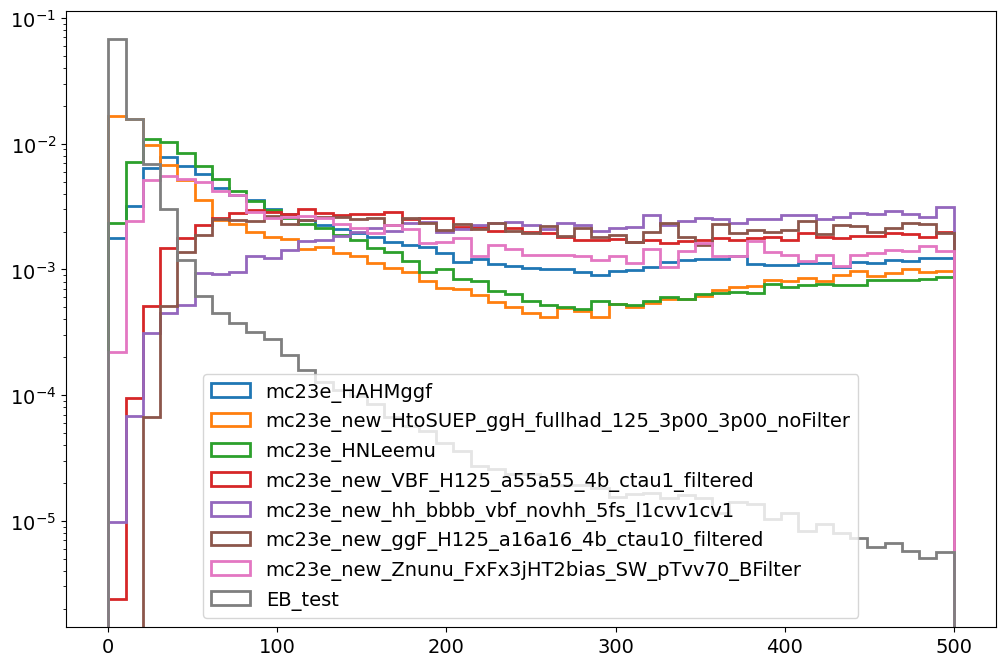

In [18]:
# Plot AD scores
plt.figure(figsize=(12, 8))
bins = np.linspace(0, 500, 50)
for tag, data_dict in datasets.items():
    if tag in skip_tags:
        continue
    plt.hist(data_dict['AD_scores'], bins=bins, histtype='step', density=True, label=tag, linewidth=2, weights=data_dict['weights'])

plt.yscale('log')
plt.legend()
plt.savefig(f'{plots_path}/AD_scores_histograms.png')
plt.show()
plt.close()

<>:24: SyntaxWarning: invalid escape sequence '\e'
<>:24: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_434341/2417423679.py:24: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(fpr, tpr, label=f'{tag} (auc = {auroc:.2f}, $\epsilon$={eff:.2e})')


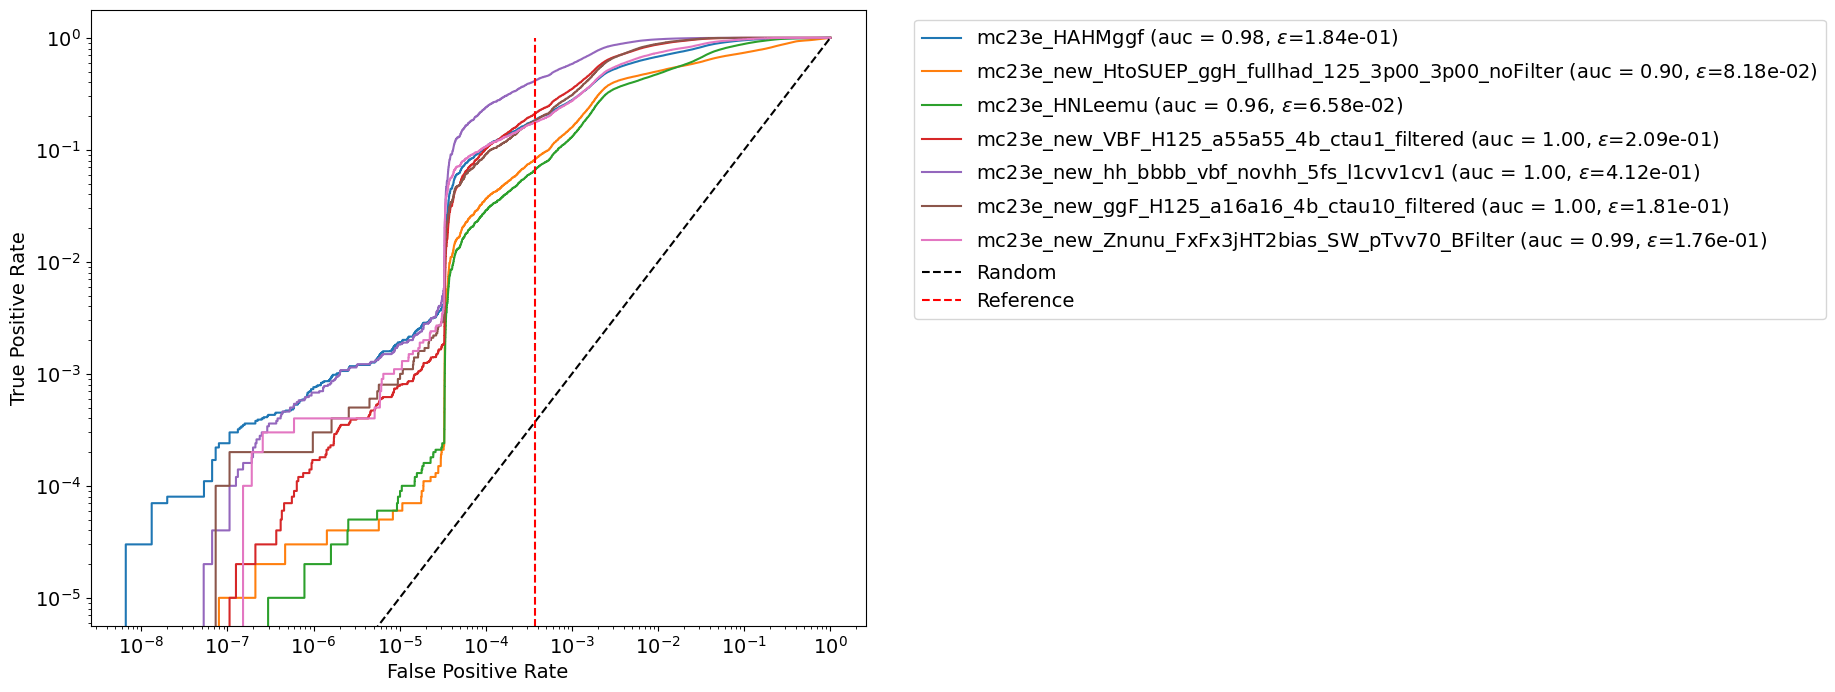

In [19]:
# ROC curve
target_FPR=3.7*pow(10, -4)
plt.figure(figsize=(10, 8))
    
bkg_scores = datasets['EB_test']['AD_scores']
bkg_weights = datasets['EB_test']['weights']

for tag, data_dict in datasets.items():
    if 'EB' in tag:
        continue

    sig_scores = data_dict['AD_scores']
    sig_weights = data_dict['weights']

    combined_scores = np.concatenate([bkg_scores, sig_scores], axis=0)
    combined_labels = np.concatenate([np.zeros_like(bkg_scores), np.ones_like(sig_scores)], axis=0)
    combined_weights = np.concatenate([bkg_weights, sig_weights], axis=0)

    fpr, tpr, thresholds = roc_curve(combined_labels, combined_scores, sample_weight=combined_weights)
    idx = np.argmin(np.abs(fpr - target_FPR))
    eff = tpr[idx]
    auroc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{tag} (auc = {auroc:.2f}, $\epsilon$={eff:.2e})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.plot([target_FPR, target_FPR], [0, 1], 'r--', label='Reference')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.yscale('log')
plt.xscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig(f'{plots_path}/roc_curves.png')
plt.show()
plt.close()

In [40]:
def save_subdicts_to_h5(main_dict, save_dir):
    """
    Saves each sub-dictionary of NumPy arrays in the main_dict to separate HDF5 files.

    Args:
        main_dict (dict): A dictionary of dictionaries where the innermost values are NumPy arrays.
        save_dir (str): The directory where the HDF5 files will be saved.
    """
    # Ensure the save directory exists
    os.makedirs(save_dir, exist_ok=True)

    for sub_dict_name, sub_dict in main_dict.items():
        file_path = os.path.join(save_dir, f"{sub_dict_name}.h5")
        with h5py.File(file_path, 'w') as f:
            for key, arr in sub_dict.items():
                f.create_dataset(key, data=arr)
        print(f"Saved {sub_dict_name} to {file_path}")

In [41]:
for tag, data_dict in datasets.items():
    print(tag)
    for key, value in data_dict.items():
        print(f'{key}: {value.shape}')

mc23e_HAHMggf
data: (100000, 15, 4)
event_numbers: (100000,)
run_numbers: (100000,)
topo2A_AD_scores: (100000,)
weights: (100000,)
x0_latent: torch.Size([100000, 15, 3])
torch_mask: torch.Size([100000, 15, 1])
AD_scores: (100000,)
mc23e_new_HtoSUEP_ggH_fullhad_125_3p00_3p00_noFilter
data: (99999, 15, 4)
event_numbers: (99999,)
run_numbers: (99999,)
topo2A_AD_scores: (99999,)
weights: (99999,)
x0_latent: torch.Size([99999, 15, 3])
torch_mask: torch.Size([99999, 15, 1])
AD_scores: (99999,)
mc23e_HNLeemu
data: (100000, 15, 4)
event_numbers: (100000,)
run_numbers: (100000,)
topo2A_AD_scores: (100000,)
weights: (100000,)
x0_latent: torch.Size([100000, 15, 3])
torch_mask: torch.Size([100000, 15, 1])
AD_scores: (100000,)
mc23e_new_VBF_H125_a55a55_4b_ctau1_filtered
data: (100000, 15, 4)
event_numbers: (100000,)
run_numbers: (100000,)
topo2A_AD_scores: (100000,)
weights: (100000,)
x0_latent: torch.Size([100000, 15, 3])
torch_mask: torch.Size([100000, 15, 1])
AD_scores: (100000,)
mc23e_new_hh_bb

In [42]:
for tag, data_dict in datasets.items():
    for key, value in data_dict.items():
        if isinstance(value, torch.Tensor):
            data_dict[key] = value.cpu().numpy()

In [43]:
data_dir = '/pscratch/sd/m/mcohen54/data/processed_data/EB_v2'
os.makedirs(data_dir, exist_ok=True)
save_subdicts_to_h5(datasets, data_dir)

Saved mc23e_HAHMggf to /pscratch/sd/m/mcohen54/data/processed_data/EB_v2/mc23e_HAHMggf.h5
Saved mc23e_new_HtoSUEP_ggH_fullhad_125_3p00_3p00_noFilter to /pscratch/sd/m/mcohen54/data/processed_data/EB_v2/mc23e_new_HtoSUEP_ggH_fullhad_125_3p00_3p00_noFilter.h5
Saved mc23e_HNLeemu to /pscratch/sd/m/mcohen54/data/processed_data/EB_v2/mc23e_HNLeemu.h5
Saved mc23e_new_VBF_H125_a55a55_4b_ctau1_filtered to /pscratch/sd/m/mcohen54/data/processed_data/EB_v2/mc23e_new_VBF_H125_a55a55_4b_ctau1_filtered.h5
Saved mc23e_new_hh_bbbb_vbf_novhh_5fs_l1cvv1cv1 to /pscratch/sd/m/mcohen54/data/processed_data/EB_v2/mc23e_new_hh_bbbb_vbf_novhh_5fs_l1cvv1cv1.h5
Saved mc23e_new_ggF_H125_a16a16_4b_ctau10_filtered to /pscratch/sd/m/mcohen54/data/processed_data/EB_v2/mc23e_new_ggF_H125_a16a16_4b_ctau10_filtered.h5
Saved mc23e_new_Znunu_FxFx3jHT2bias_SW_pTvv70_BFilter to /pscratch/sd/m/mcohen54/data/processed_data/EB_v2/mc23e_new_Znunu_FxFx3jHT2bias_SW_pTvv70_BFilter.h5
Saved EB_train to /pscratch/sd/m/mcohen54/data

In [18]:
def generate_samples_physics_order(
    node, num_events=1000, input_dim=3,
    n_met=1, n_muons=4, n_taus=4, n_jets=6,
    batch_size=1024
):
    """
    Generate samples with a specific number of each physics object, in the order:
    [6 jets, 4 muons, 4 taus, 1 MET], zero-padded per object type.
    The type index is set to 1 (jet), 2 (muon), 3 (tau), 4 (MET), 0 (padding).
    """

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    num_objects = 15
    type_idx = [0] * num_objects
    # Jets (first 6)
    for i in range(0, 6):
        type_idx[i] = 1 if i < n_jets else 0
    # Taus (next 4) 
    for i in range(6, 10):
        type_idx[i] = 2 if (i - 6) < n_taus else 0
    # Muons (next 4)
    for i in range(10, 14):
        type_idx[i] = 3 if (i - 10) < n_muons else 0
    # MET (last 1)
    type_idx[14] = 4 if n_met > 0 else 0

    # Repeat for all events
    mask = np.tile(type_idx, (num_events, 1))
    mask = mask[:, :, None]  # shape [num_events, num_objects, 1]
    mask = torch.tensor(mask, dtype=torch.float32, device=device)

    # Sample from standard normal
    x0 = torch.randn((num_events, num_objects, input_dim), device=device)

    # Set MET eta to 0 in base distribution (consistent with training)
    x0[:, -1, 1] = 0  # MET eta = 0

    t_span = torch.linspace(0., 1., 2, device=device)
    outputs = []

    # Process in batches
    for i in range(0, num_events, batch_size):
        xb = x0[i:i+batch_size]
        mb = mask[i:i+batch_size]
        binary_mask = (mb > 0).float()

        with torch.no_grad():
            traj = node.trajectory(xb, t_span=t_span)
            x1_b = traj[-1] * binary_mask  # apply mask

            # Ensure MET eta remains 0 in final samples
            x1_b[:, -1, 1] = 0  # MET eta = 0

        outputs.append(x1_b.cpu())

    x1 = torch.cat(outputs, dim=0)
    return x1.numpy(), mask.cpu().numpy()

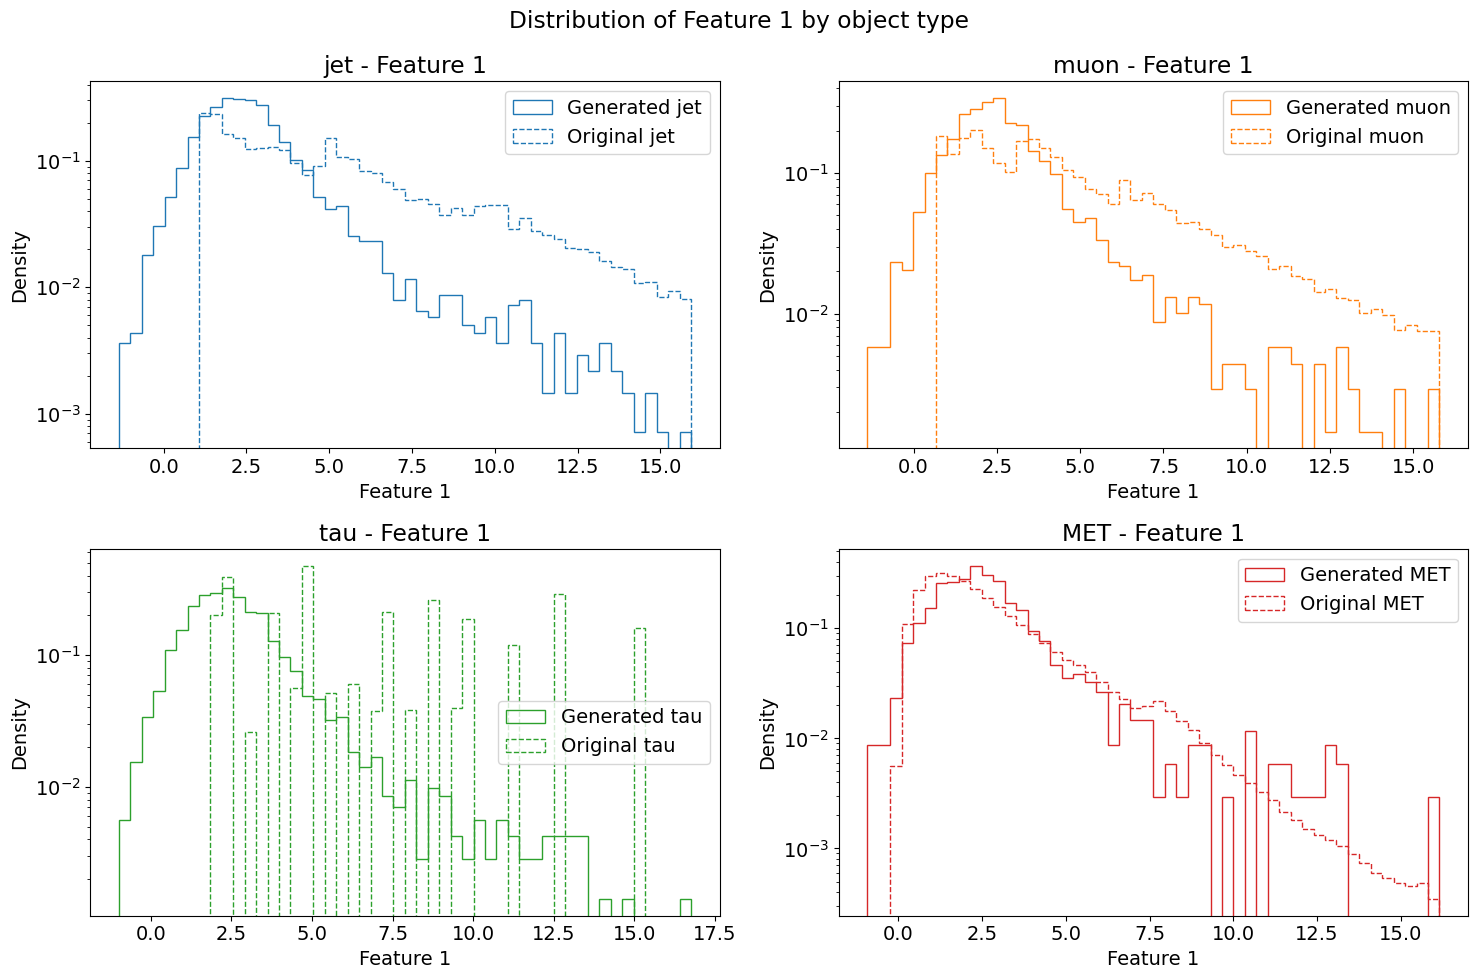

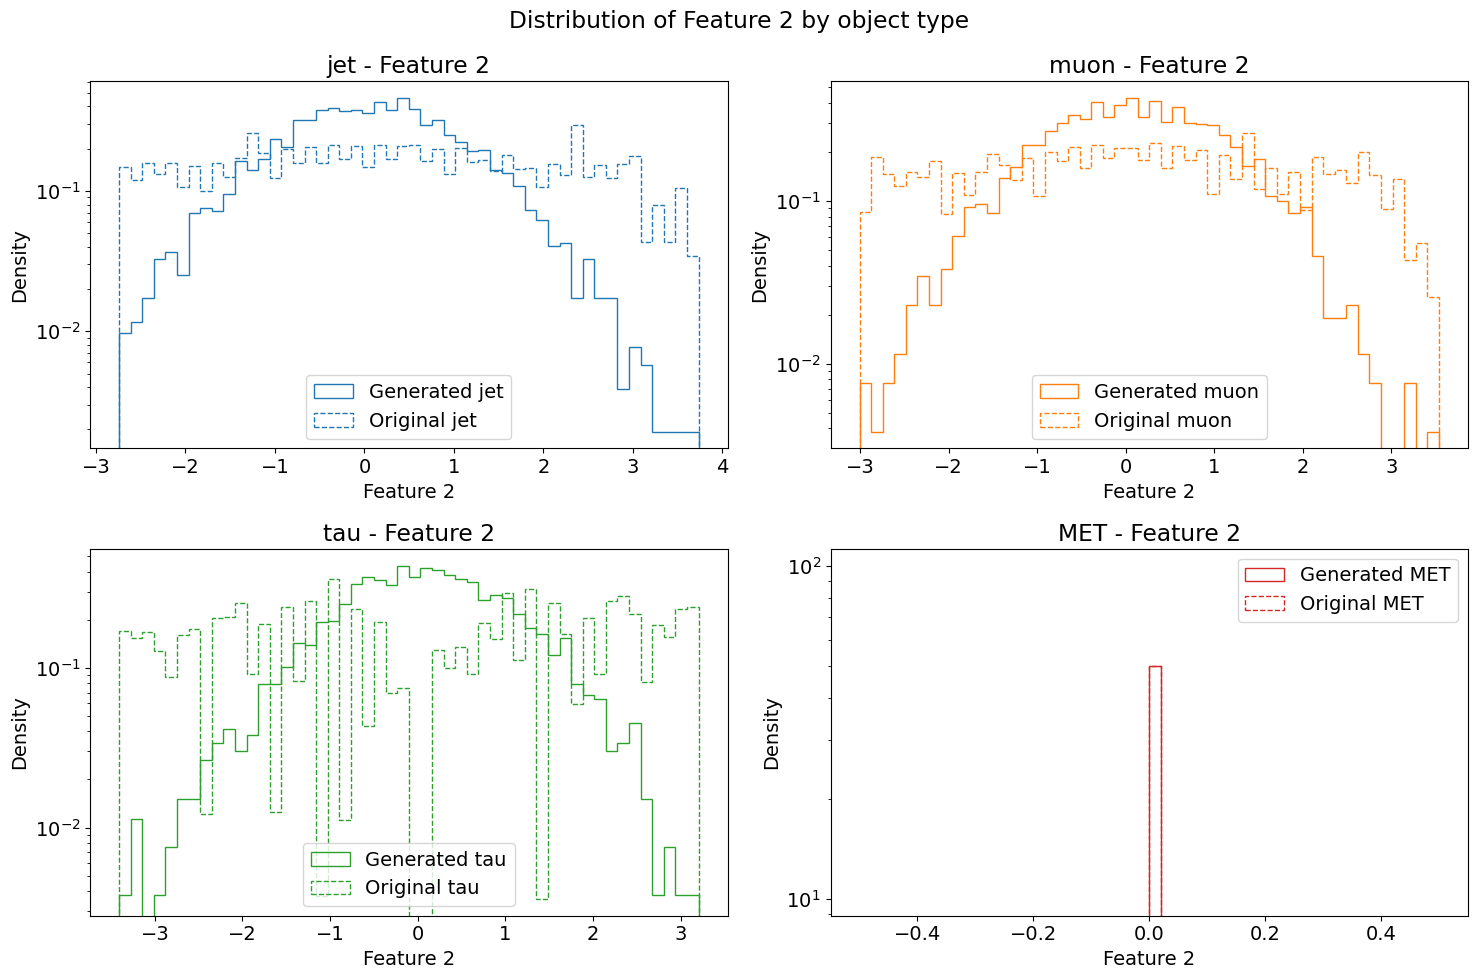

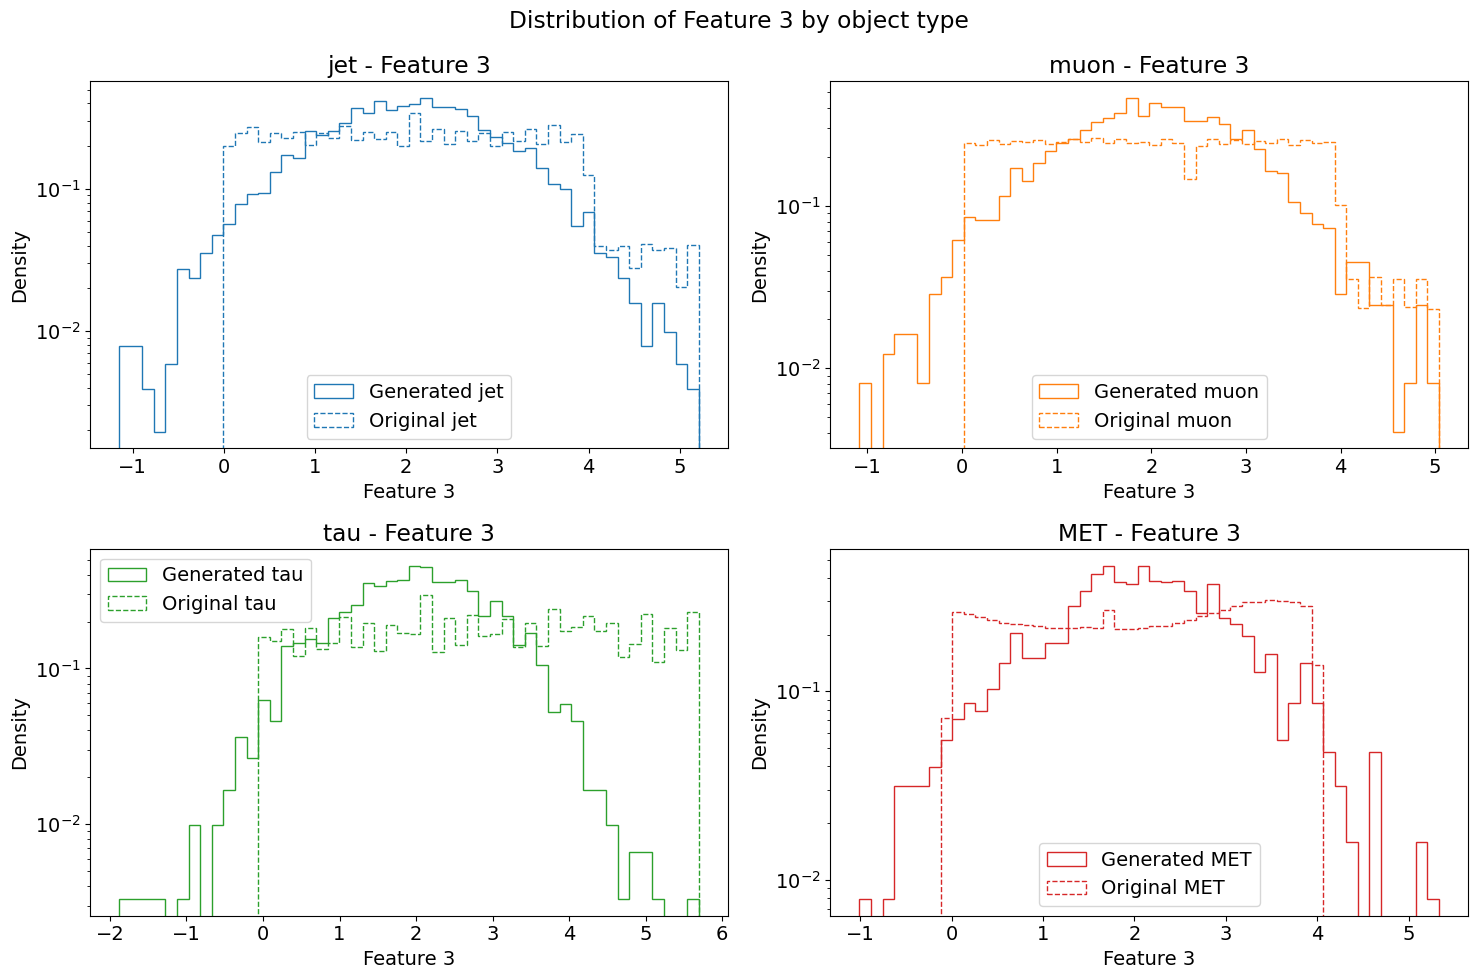

In [19]:
# # 1 MET, 2 muons, 2 taus, 4 jets (rest padded)
gen_samples, gen_mask = generate_samples_physics_order(
    node, num_events=1000, input_dim=3,
    n_met=1, n_muons=2, n_taus=2, n_jets=4
)

feature_names = ['Feature 1', 'Feature 2', 'Feature 3']
object_types = {1: 'jet', 2: 'muon', 3: 'tau', 4: 'MET'}
colors = ['C0', 'C1', 'C2', 'C3']

# Original data
orig_data = datasets['EB_test']['data']  # shape [N, 15, 4]
orig_features = orig_data[:, :, :3]       # [N, 15, 3]
orig_types = orig_data[:, :, 3]           # [N, 15]

for feat_idx, feat_name in enumerate(feature_names):
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    axs = axs.ravel()
    
    for obj_type, label in object_types.items():
        ax = axs[obj_type-1]  # Use object type as subplot index
        
        # Generated
        gen_mask_this = (gen_mask[:, :, 0] == obj_type)
        gen_data_this = gen_samples[:, :, feat_idx][gen_mask_this]
        # Original
        orig_mask_this = (orig_types == obj_type)
        orig_data_this = orig_features[:, :, feat_idx][orig_mask_this]
        
        # Plot
        if len(gen_data_this) > 0:
            _, bins, _ = ax.hist(gen_data_this, bins=50, histtype='step', density=True,
                   label=f'Generated {label}', color=colors[obj_type-1], linestyle='-')
        if len(orig_data_this) > 0:
            ax.hist(orig_data_this, bins=bins, histtype='step', density=True,
                   label=f'Original {label}', color=colors[obj_type-1], linestyle='dashed')
            
        ax.set_title(f'{label} - {feat_name}')
        ax.set_xlabel(feat_name)
        ax.set_ylabel('Density')
        ax.legend()
        ax.set_yscale('log')
    
    plt.suptitle(f'Distribution of {feat_name} by object type')
    plt.tight_layout()
    plt.savefig(f'{plots_path}/inverse_flow_feature_distributions_{feat_name}.png')
    plt.show()
    plt.close()

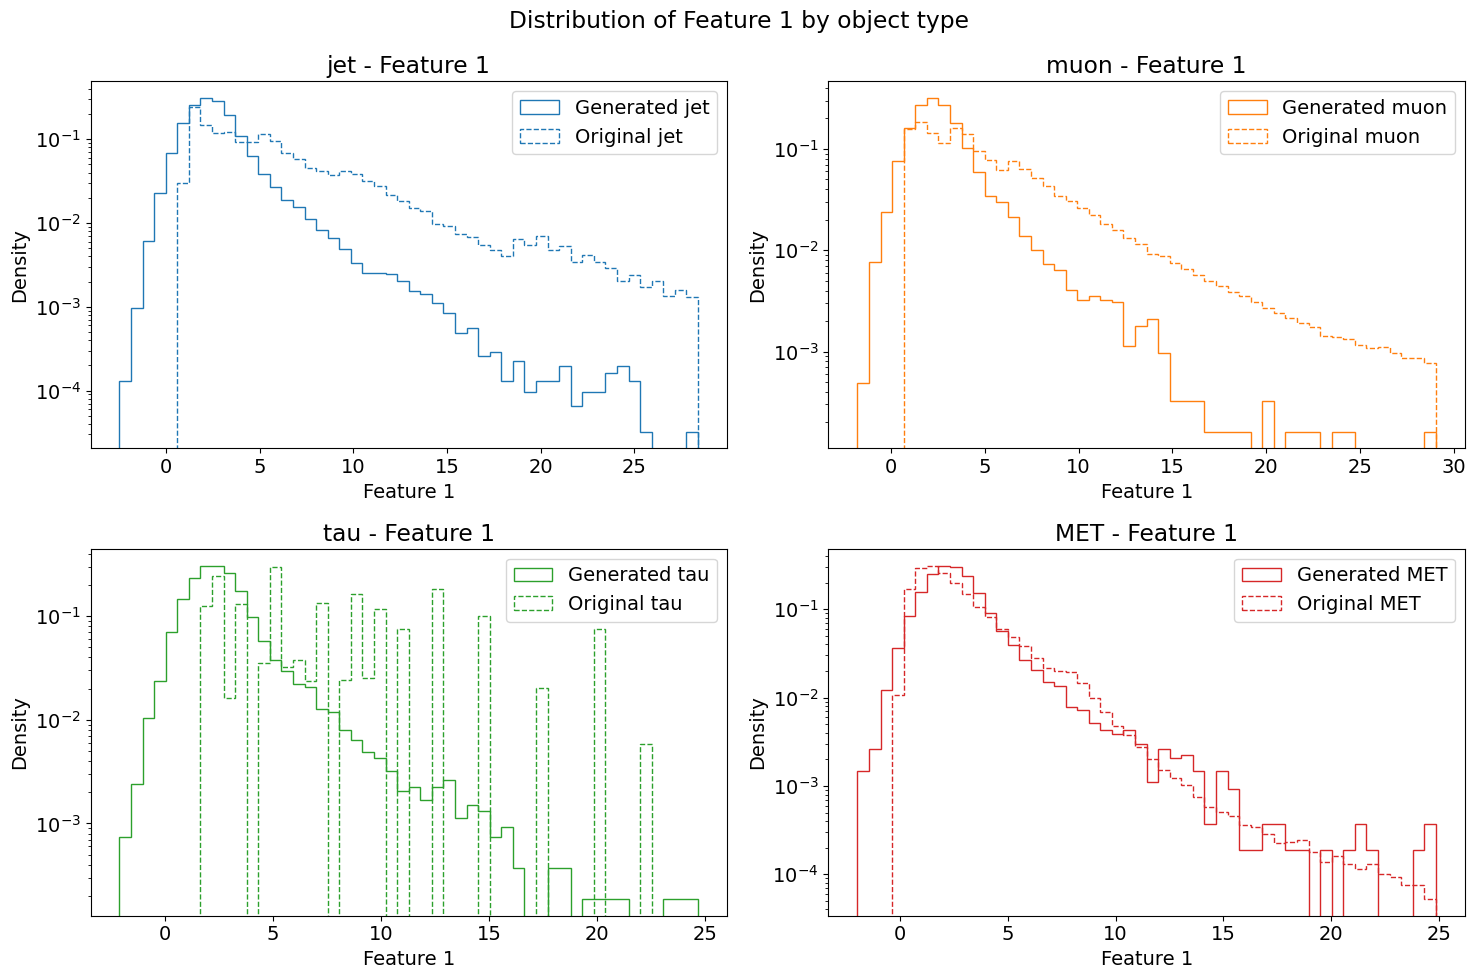

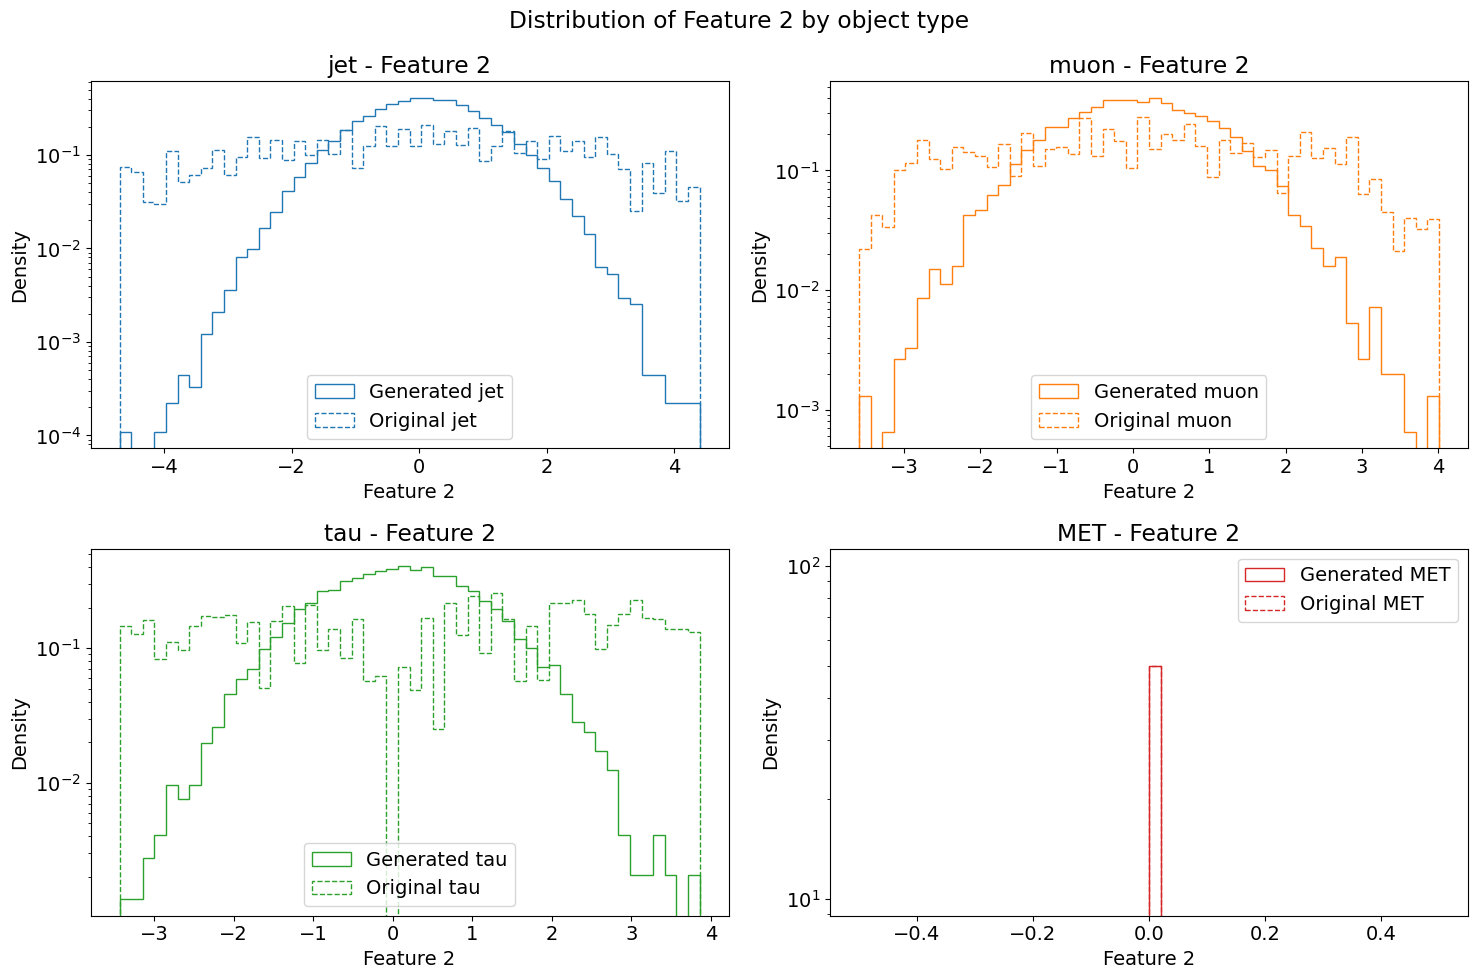

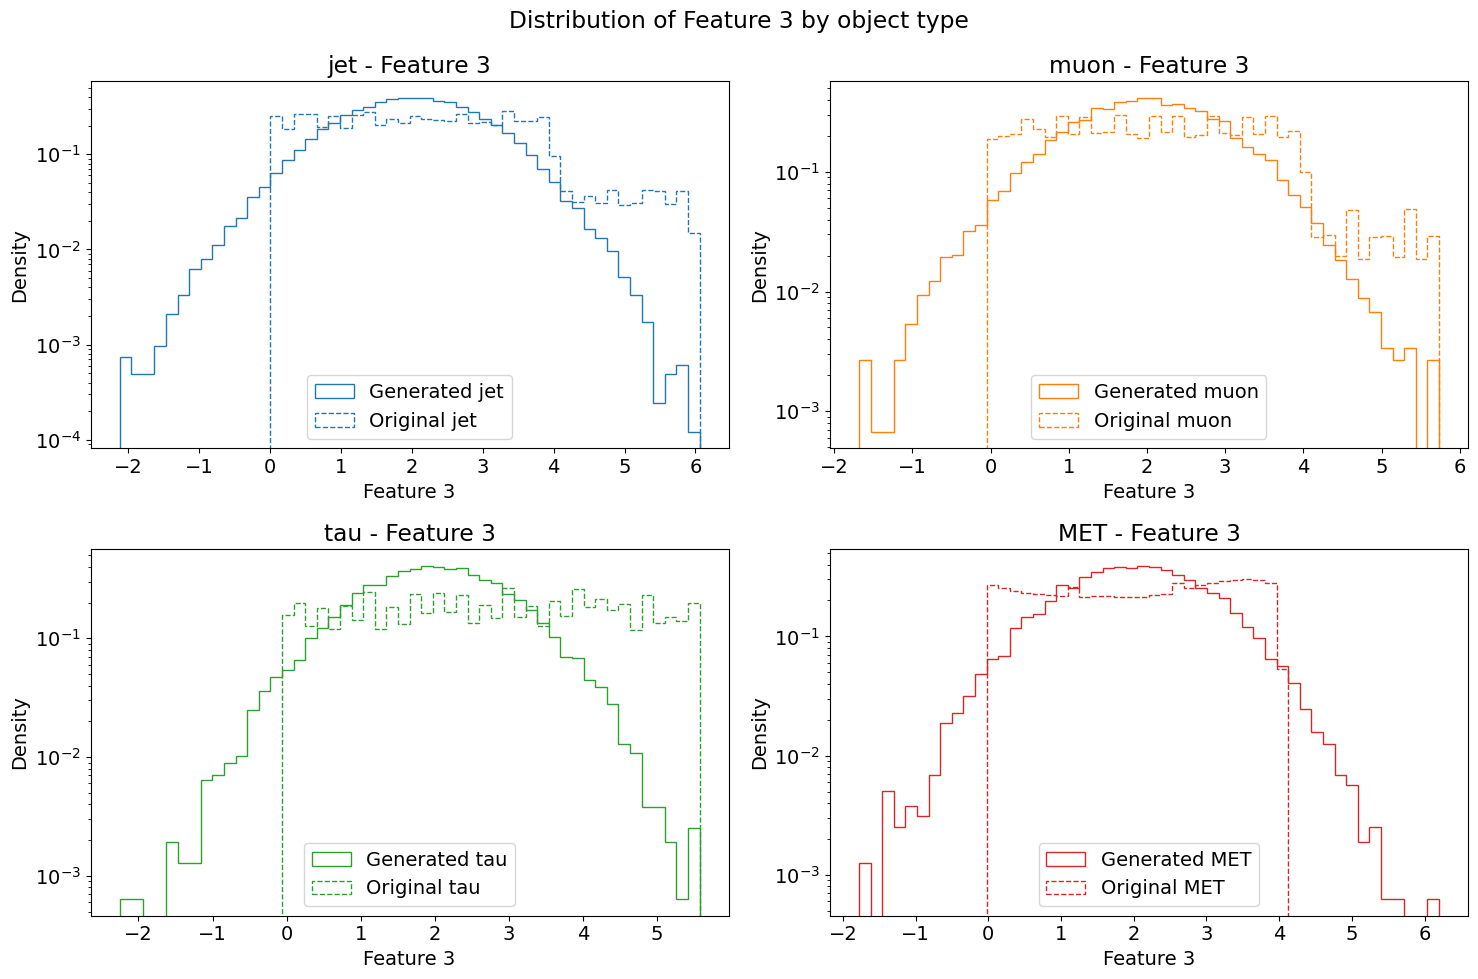

In [21]:
# # 1 MET, 2 muons, 2 taus, 4 jets (rest padded)
gen_samples, gen_mask = generate_samples_physics_order(
    node, num_events=10000, input_dim=3,
    n_met=1, n_muons=1, n_taus=1, n_jets=5
)

feature_names = ['Feature 1', 'Feature 2', 'Feature 3']
object_types = {1: 'jet', 2: 'muon', 3: 'tau', 4: 'MET'}
colors = ['C0', 'C1', 'C2', 'C3']

# Original data
orig_data = datasets['EB_test']['data']  # shape [N, 15, 4]
orig_features = orig_data[:, :, :3]       # [N, 15, 3]
orig_types = orig_data[:, :, 3]           # [N, 15]

for feat_idx, feat_name in enumerate(feature_names):
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    axs = axs.ravel()
    
    for obj_type, label in object_types.items():
        ax = axs[obj_type-1]  # Use object type as subplot index
        
        # Generated
        gen_mask_this = (gen_mask[:, :, 0] == obj_type)
        gen_data_this = gen_samples[:, :, feat_idx][gen_mask_this]
        # Original
        orig_mask_this = (orig_types == obj_type)
        orig_data_this = orig_features[:, :, feat_idx][orig_mask_this]
        
        # Plot
        if len(gen_data_this) > 0:
            _, bins, _ = ax.hist(gen_data_this, bins=50, histtype='step', density=True,
                   label=f'Generated {label}', color=colors[obj_type-1], linestyle='-')
        if len(orig_data_this) > 0:
            ax.hist(orig_data_this, bins=bins, histtype='step', density=True,
                   label=f'Original {label}', color=colors[obj_type-1], linestyle='dashed')
            
        ax.set_title(f'{label} - {feat_name}')
        ax.set_xlabel(feat_name)
        ax.set_ylabel('Density')
        ax.legend()
        ax.set_yscale('log')
    
    plt.suptitle(f'Distribution of {feat_name} by object type')
    plt.tight_layout()
    plt.savefig(f'{plots_path}/inverse_flow_feature_distributions_{feat_name}.png')
    plt.show()
    plt.close()